In [1]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 35.3 MB/s eta 0:00:00


In [2]:
import pickle

def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

X_stress = load_pickle("X_stress.pkl")
X_strain = load_pickle("X_strain.pkl")
y_stress = load_pickle("y_stress.pkl")
y_strain = load_pickle("y_strain.pkl")

'''5 values:
Q (параметр нагрузки/деформации)
k ( коэффициент калибровочного участка)
alpha (угол, геометрия)
mu (коэффициент трения)
v (скорость)
'''
print("X_stress:", type(X_stress), getattr(X_stress, "shape", None))
print("X_strain:", type(X_strain), getattr(X_strain, "shape", None))
print("y_stress:", type(y_stress), getattr(y_stress, "shape", None))
print("y_strain:", type(y_strain), getattr(y_strain, "shape", None))

print("\nExample values:")
print("X_stress[0]:", X_stress[0])
print("y_stress[0]:", y_stress[0])


X_stress: <class 'numpy.ndarray'> (4, 2028, 5)
X_strain: <class 'numpy.ndarray'> (4, 2438, 5)
y_stress: <class 'numpy.ndarray'> (4, 2028, 20)
y_strain: <class 'numpy.ndarray'> (4, 2438, 20)

Example values:
X_stress[0]: [[ 0.1    0.     8.     0.1   10.   ]
 [ 0.1    0.     8.     0.025 10.   ]
 [ 0.1    0.     8.     0.05  10.   ]
 ...
 [ 0.15   0.    20.     0.1    5.   ]
 [ 0.15   0.    20.     0.025  5.   ]
 [ 0.15   0.    20.     0.05   5.   ]]
y_stress[0]: [[-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 [-132.998   -129.095   -118.699   ...  118.626    134.583    140.446  ]
 ...
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]
 [-121.443   -116.65    -106.736   ...   86.1895    94.37975   97.38555]]


[I 2026-05-19 15:37:57,361] A new study created in memory with name: no-name-d09f2cc2-6dbe-4416-8a97-746346f11646


✓ JAX GPU detected: NVIDIA A100-SXM4-40GB
  jax version    : 0.7.2
  flax version   : 0.11.2
  optax version  : 0.2.8
  jax devices    : [CudaDevice(id=0)]
  → A100 detected: TF32 matmul auto-enabled by XLA

══════════════════════════════════════════════════════════════════════════
ОБУЧАЮЩАЯ ВЫБОРКА  (X_stress.pkl / y_stress.pkl, cleaned, Abaqus convention, МПа)
══════════════════════════════════════════════════════════════════════════
X_pinn : (40560, 6)   [Q, k, α, μ, v, r]
y_pinn : (40560, 4)   [σ_rr, σ_θθ, σ_zz, τ_rz]
Mapping: stress_33→σ_rr | stress_11→σ_θθ | stress_22→σ_zz | stress_12→τ_rz

Диапазоны y (физические FEM значения, МПа):
  sigma_rr  : [    -418.6,      0.1331]   mean_abs=109.6
  sigma_tt  : [      -292,       282.6]   mean_abs=62.92
  sigma_zz  : [    -299.6,       214.1]   mean_abs=58.07
  tau_rz    : [    -301.3,          25]   mean_abs=47.92

BC контроль на границе data range (r_norm=1 = 75% R_phys):
  σ_rr at r_norm=1: mean=-5.911  max|.|=367.4  (НЕ ноль — это не

[I 2026-05-19 15:39:35,538] Trial 0 finished with value: 23.31847427247852 and parameters: {'n_layers': 6, 'n_units_0': 81, 'n_units_1': 34, 'n_units_2': 178, 'n_units_3': 60, 'n_units_4': 65, 'n_units_5': 90, 'activation': 'tanh', 'learning_rate': 0.0008403670011056603, 'batch_size': 32, 'optimizer': 'Adam', 'max_epochs': 535, 'lambda_physics': 0.13166956701868446, 'lambda_bc': 0.01737262342039811, 'lambda_profile': 0.01514114618674541, 'grad_clip': 3.144167381399651, 'weight_decay': 0.0011290377764907019}. Best is trial 0 with value: 23.31847427247852.
[I 2026-05-19 15:40:33,816] Trial 1 finished with value: 26.252583984636146 and parameters: {'n_layers': 5, 'n_units_0': 124, 'n_units_1': 170, 'n_units_2': 40, 'n_units_3': 158, 'n_units_4': 127, 'activation': 'tanh', 'learning_rate': 7.232785469199838e-05, 'batch_size': 32, 'optimizer': 'Adam', 'max_epochs': 319, 'lambda_physics': 0.0012521667760832084, 'lambda_bc': 0.15854488994075114, 'lambda_profile': 0.01600640295666349, 'grad_cl

Best params: {'n_layers': 5, 'n_units_0': 193, 'n_units_1': 81, 'n_units_2': 127, 'n_units_3': 187, 'n_units_4': 253, 'activation': 'tanh', 'learning_rate': 0.0014408502430049135, 'batch_size': 16, 'optimizer': 'AdamW', 'max_epochs': 342, 'lambda_physics': 0.002457078325685056, 'lambda_bc': 4.955909540291753, 'lambda_profile': 0.971859035448273, 'grad_clip': 2.469334512874828, 'weight_decay': 0.00425697431929996, 'r_extrap': 1.5}

★ Optuna search закончен за 1162.5 с  (≈ 58.1 с / trial)
  best_inner_val (worst-fold macro RMSE): 18.5868
  best_params:
    n_layers           = 5
    n_units_0          = 193
    n_units_1          = 81
    n_units_2          = 127
    n_units_3          = 187
    n_units_4          = 253
    activation         = tanh
    learning_rate      = 0.00144085
    batch_size         = 16
    optimizer          = AdamW
    max_epochs         = 342
    lambda_physics     = 0.00245708
    lambda_bc          = 4.95591
    lambda_profile     = 0.971859
    grad_clip  

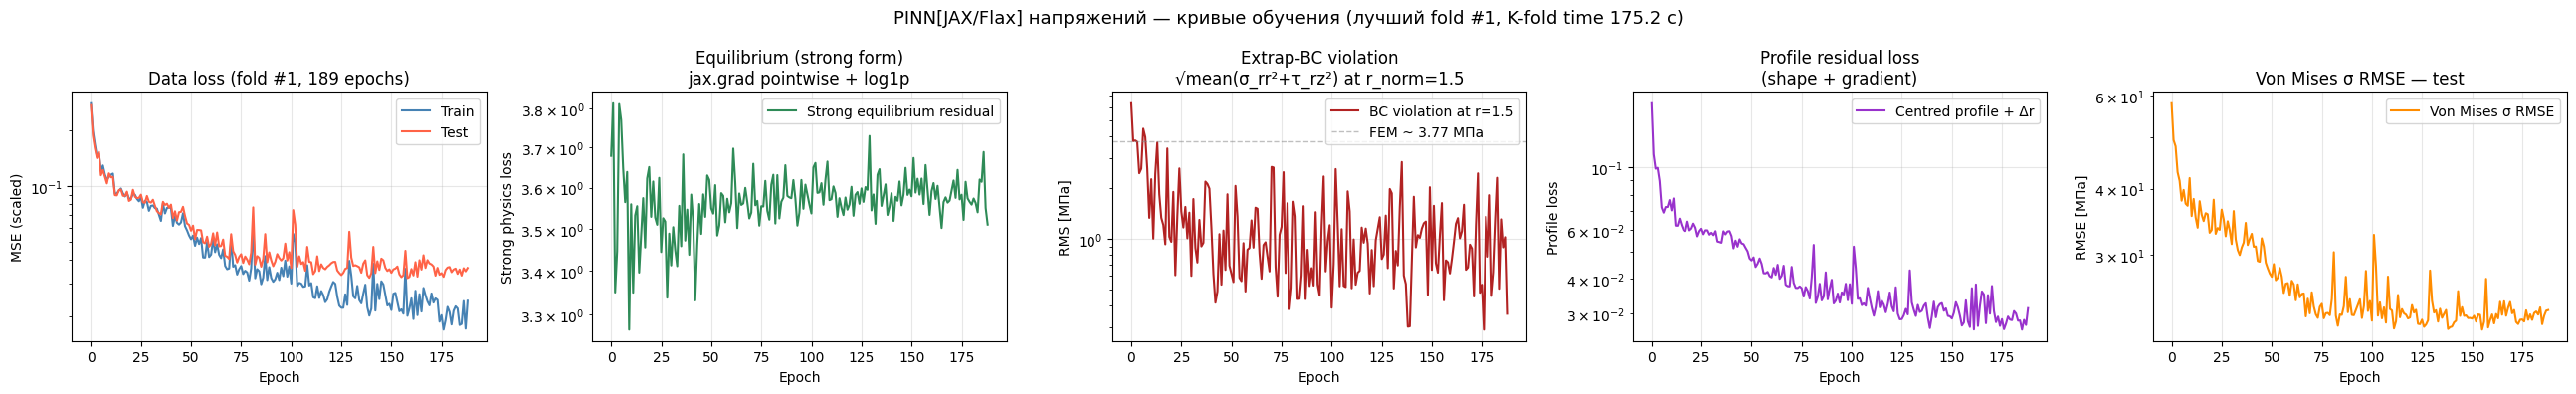

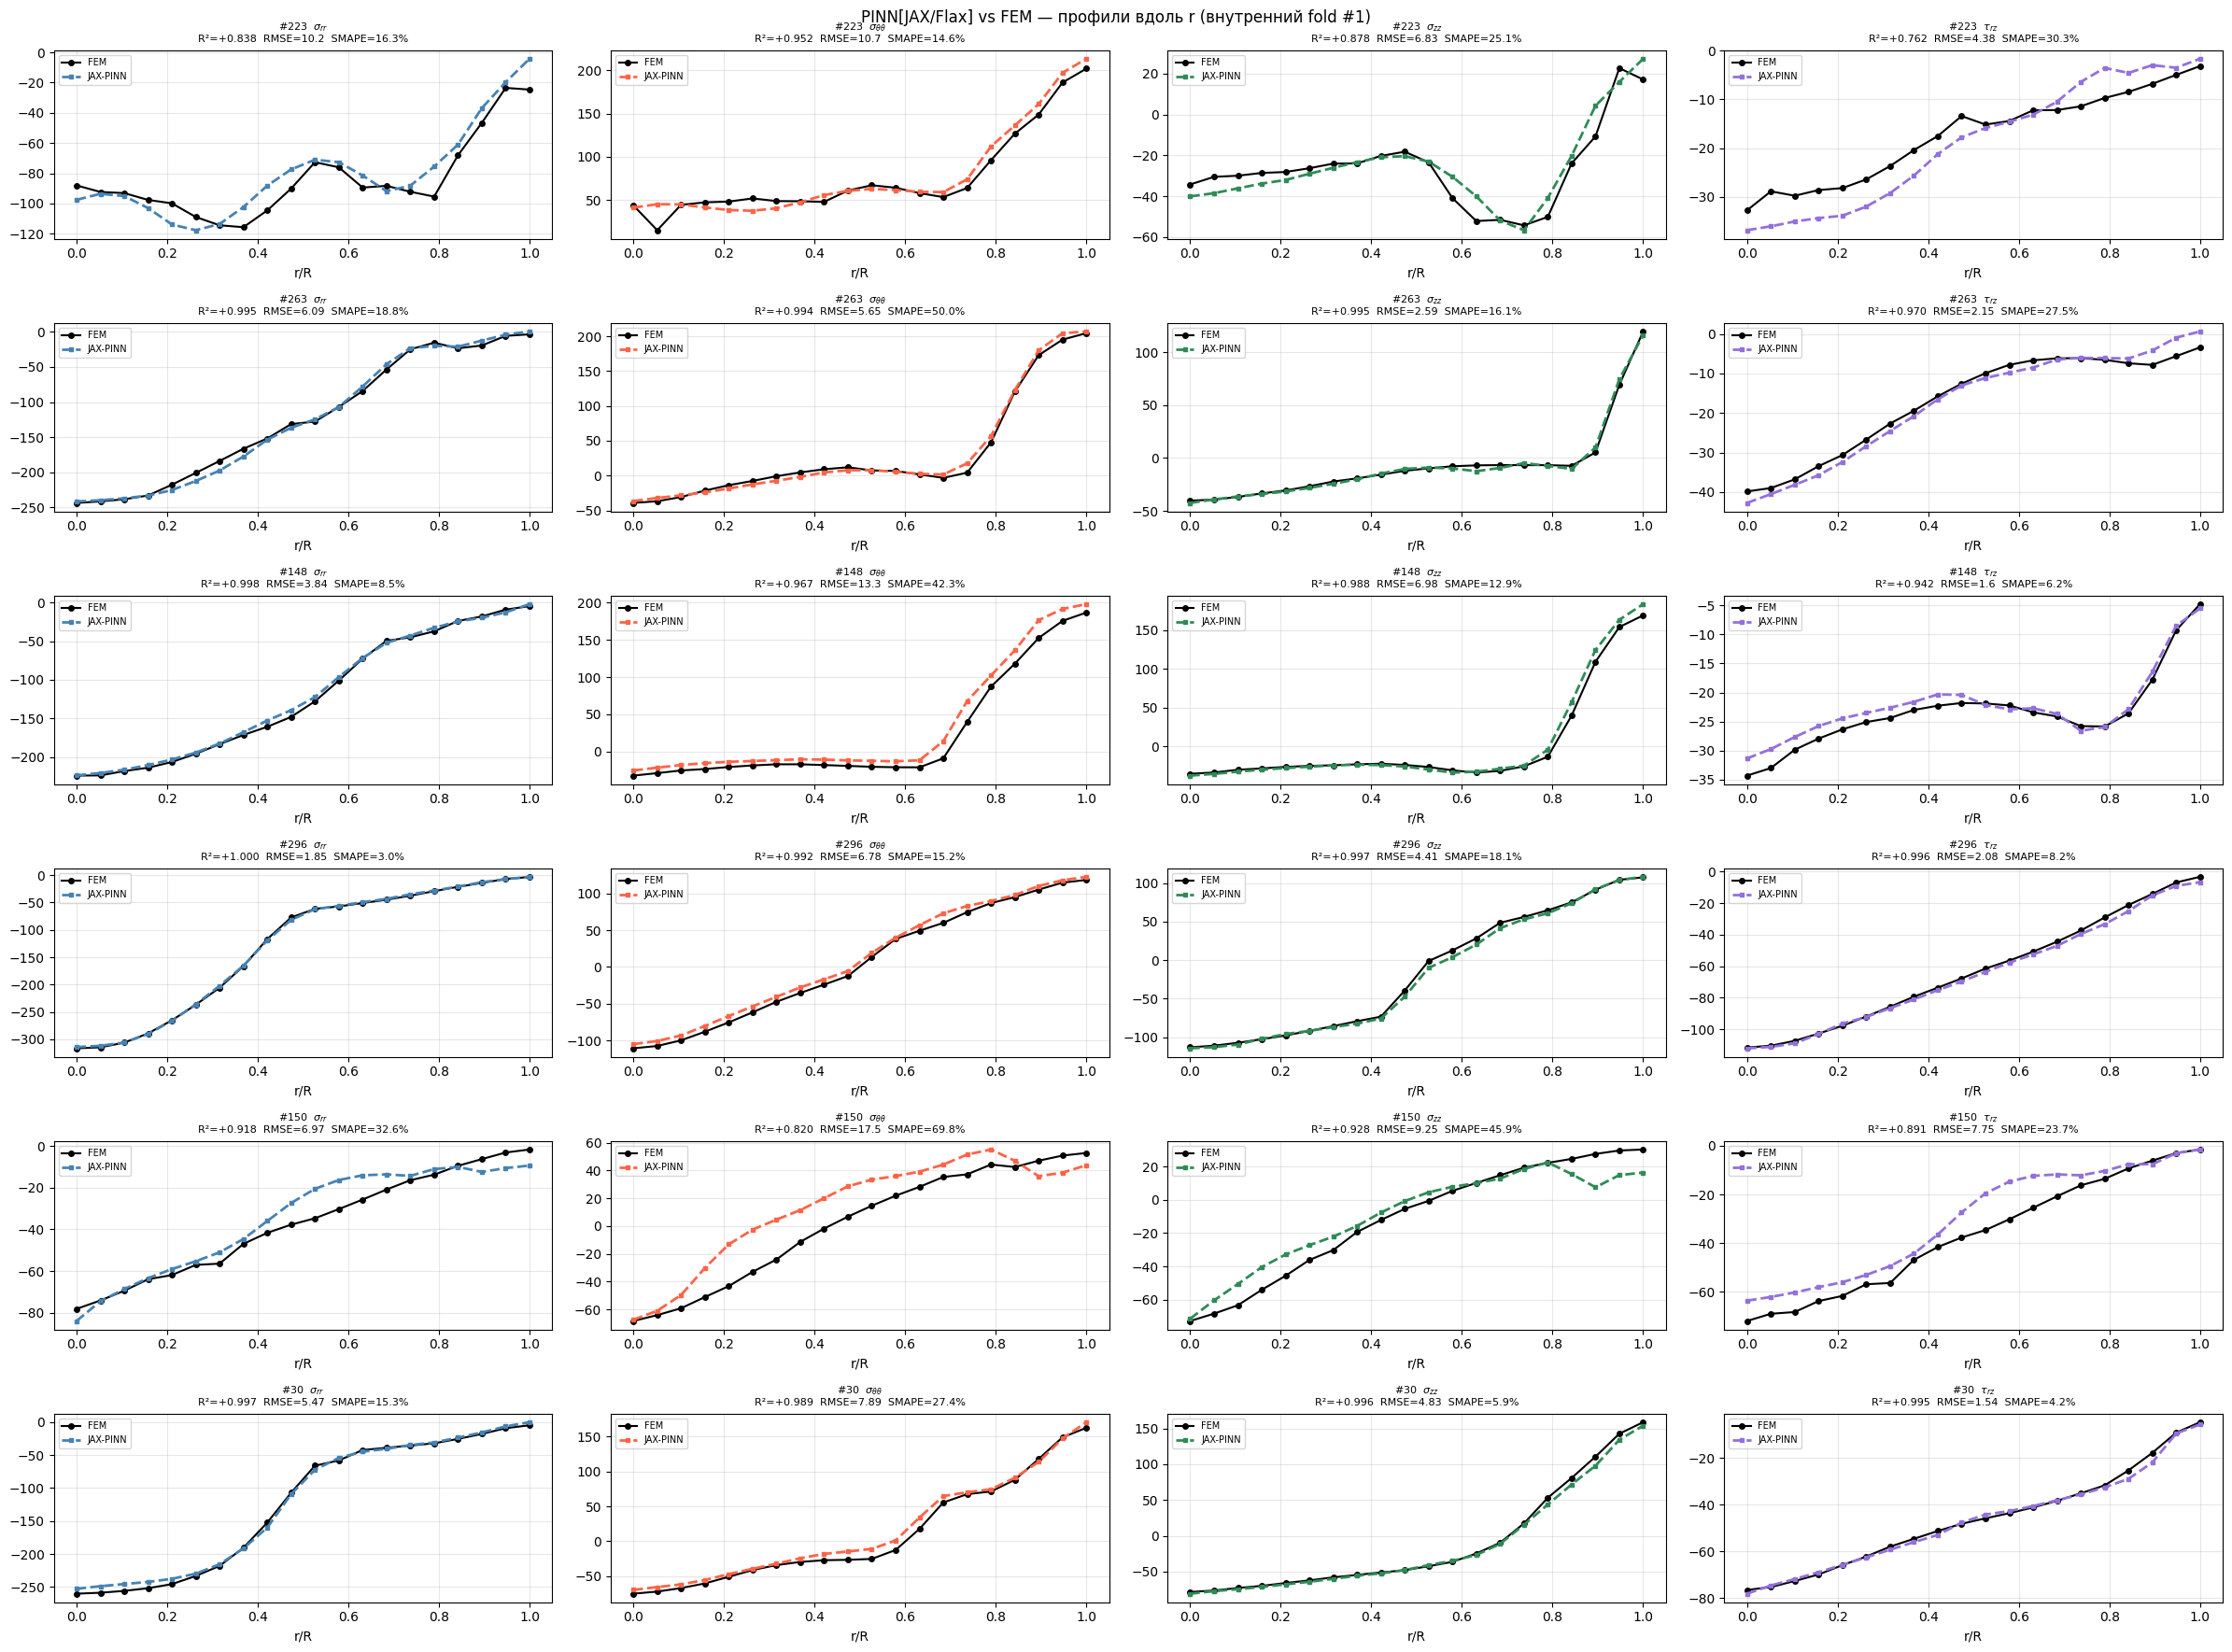

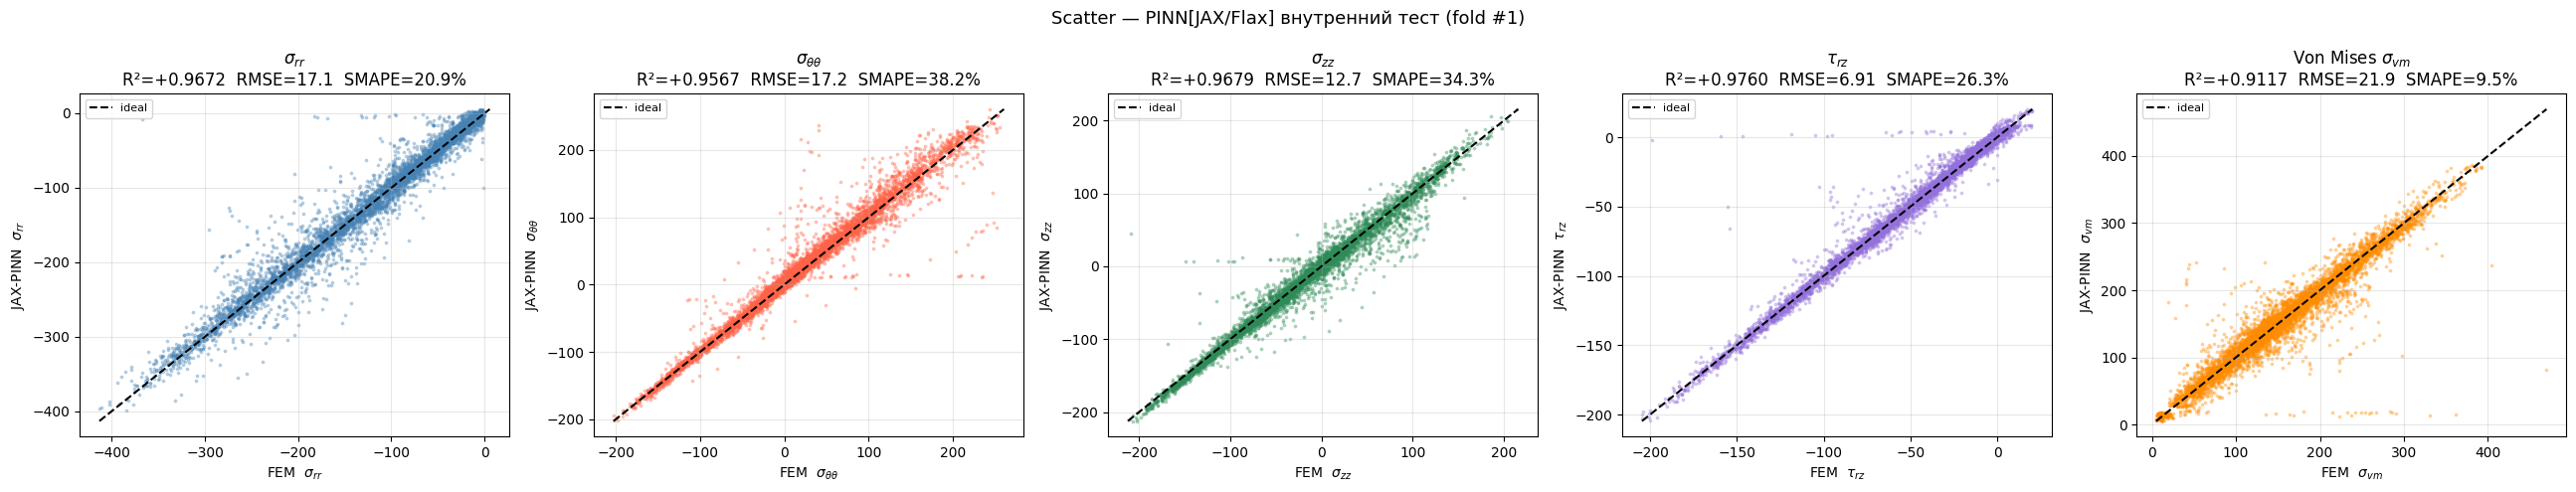


══════════════════════════════════════════════════════════════════════════
HOLDOUT VALIDATION  (304 sets, 6080 rows, 15.0% от total — never seen during training)
══════════════════════════════════════════════════════════════════════════

── Holdout — Metrics ───────────────────────────
  Explained Variance        : 0.9820
  Median AE                 : 3.7751
  MSE                       : 148.6809
  MAE                       : 6.6113
  R²                        : 0.9817
  Max Error                 : 185.1075
  AIC                       : 372452.1418
  BIC                       : 1217223.3736
  RMSE (4 comp macro)       : 11.5129
  Von Mises R²              : 0.9482
  SMAPE [%]                 : 28.4296

── Per-component RMSE / R² / SMAPE (Holdout (15% from cleaned train pkl)) ──
  sigma_rr    :  RMSE=     14.38   R²=+0.9779   SMAPE=  20.02%
  sigma_tt    :  RMSE=     15.58   R²=+0.9650   SMAPE=  36.04%
  sigma_zz    :  RMSE=     10.85   R²=+0.9773   SMAPE=  32.28%
  tau_rz      :  RMSE

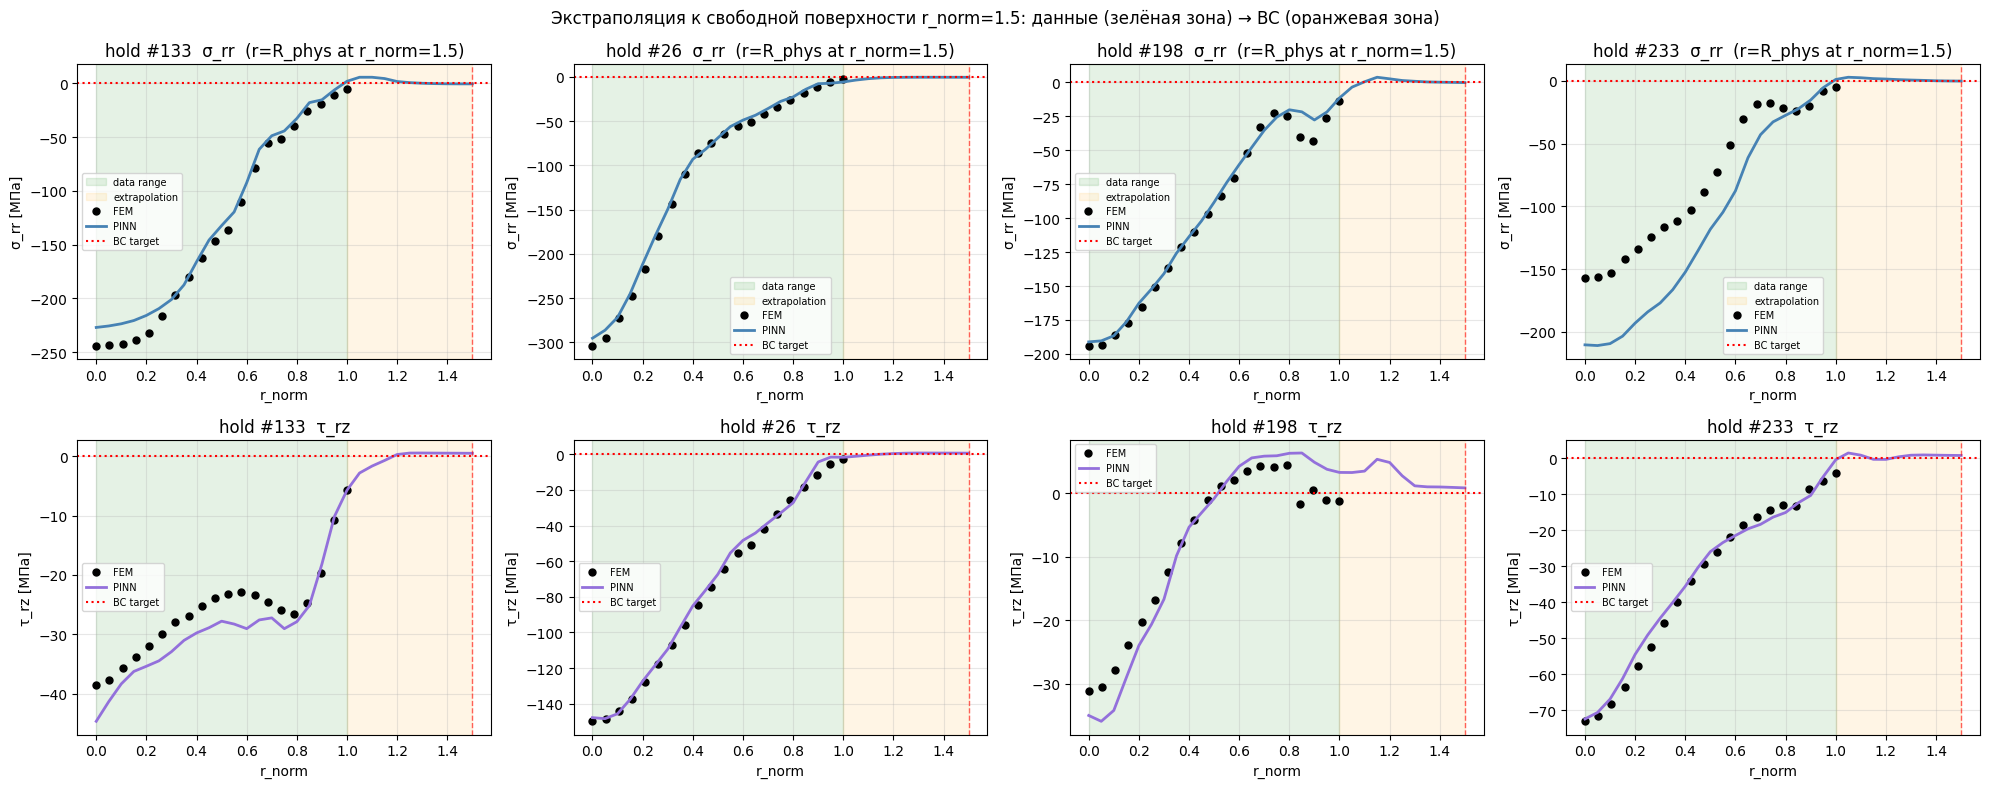

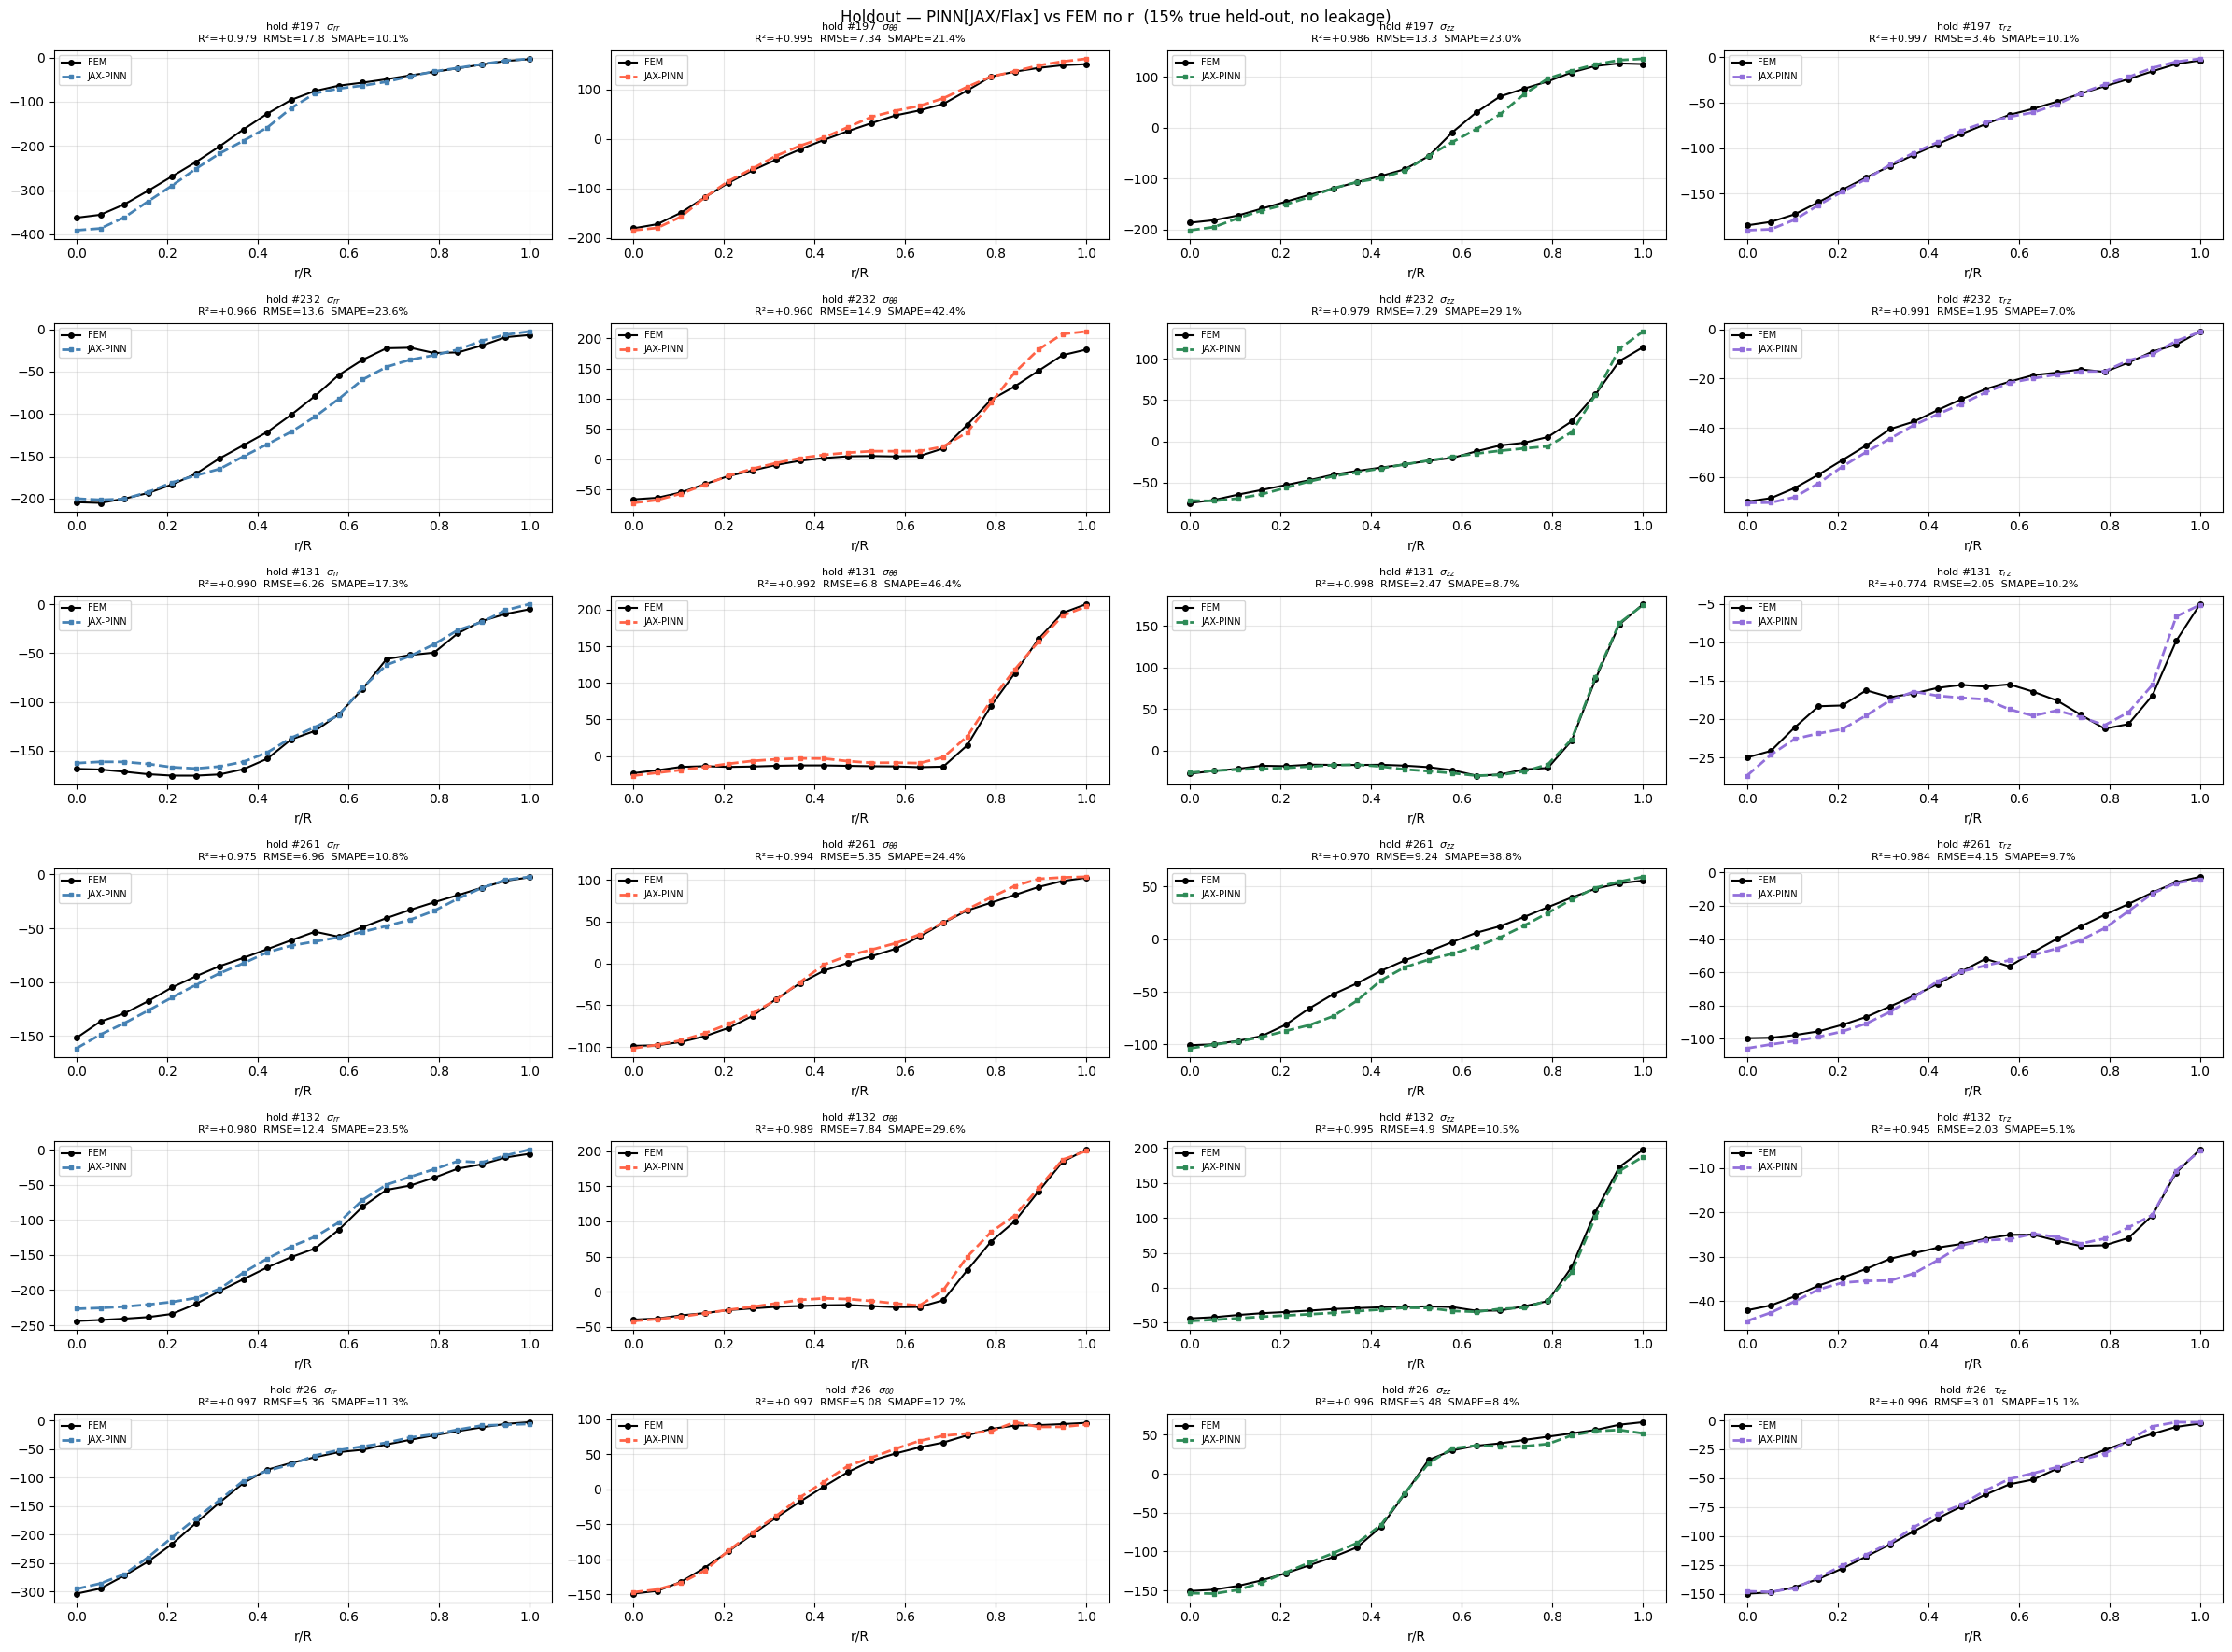

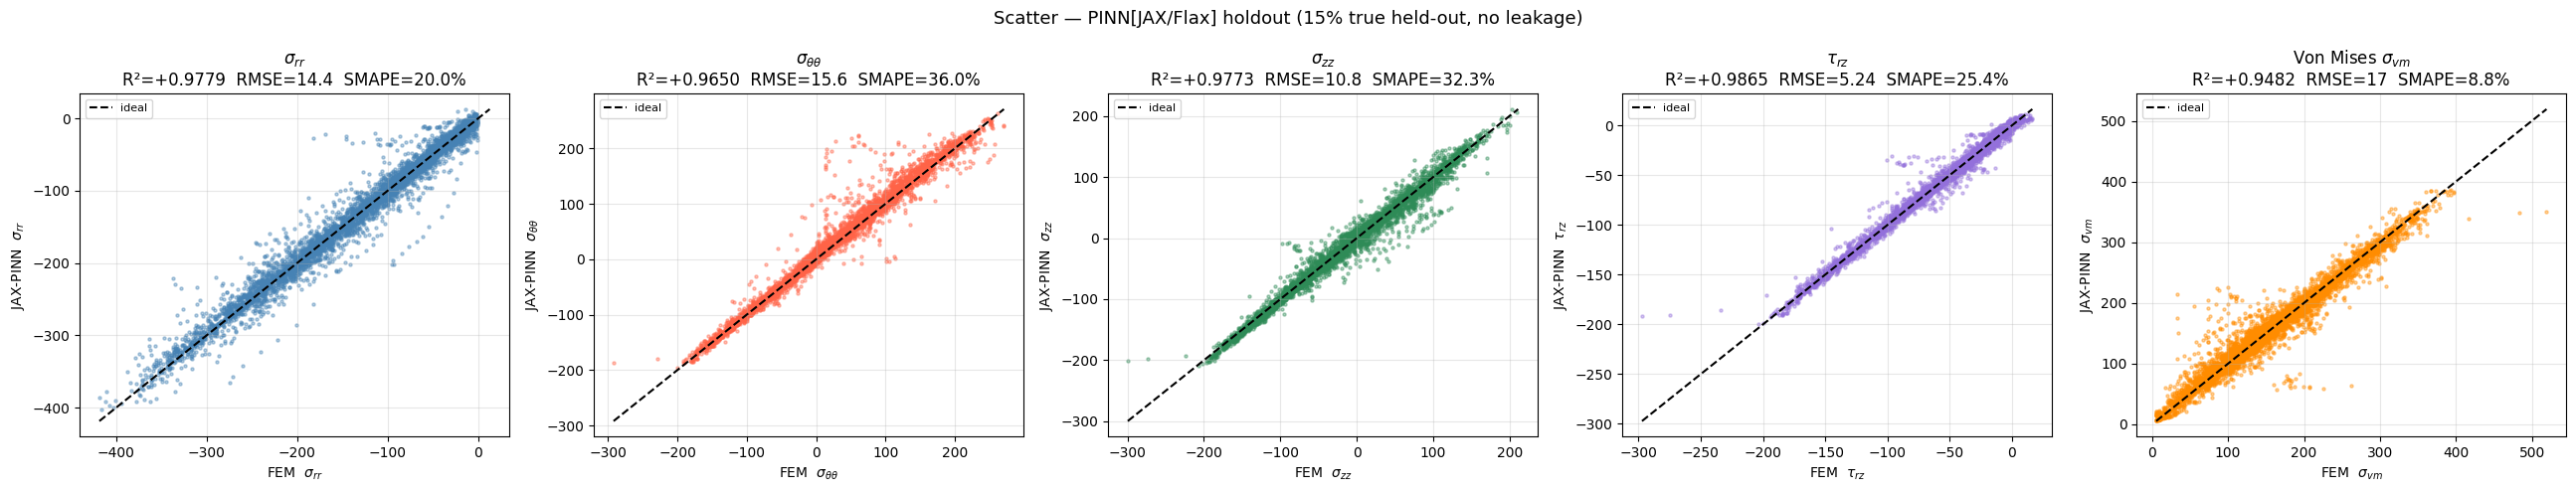


═══ PINN[JAX/Flax] СВОДНАЯ ТАБЛИЦА  ═══════════════════════════════════
                     K-Fold mean  K-Fold std   Best Fold  Holdout 15%
Explained Variance       0.97119   0.0056254    0.974983     0.981994
Median AE                4.38307    0.530037     3.83594      3.77511
MSE                      234.027     47.9752     199.335      148.681
MAE                       7.9776    0.615527      7.1372      6.61131
R²                      0.970978  0.00573765    0.974706     0.981656
Max Error                266.573     55.0249     359.761      185.107
AIC                      349,972    5,060.09     346,026      372,452
BIC                  1.17243e+06    5,059.14 1.16847e+06  1.21722e+06
RMSE (4 comp macro)      14.6914     1.54713      13.477      11.5129
Von Mises R²            0.899618   0.0379285    0.911702     0.948189
SMAPE [%]                29.6931     1.97789     29.9094      28.4296

─── Время выполнения этапов ─────────────────────────────
  Optuna search        : 116

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ pinn_model_jax.pkl


In [3]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import importlib, pickle, time
from pathlib import Path
import pinn_model_jax
importlib.reload(pinn_model_jax)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from sklearn.metrics import r2_score, mean_squared_error

from pinn_model_jax import (
    build_stress_dataset,
    do_optuna_pinn_jax,
    kfold_test_best_model_pinn_jax,
    predict_with_pinn_jax,
    cuml_scorer_pinn_jax,
    per_component_report,
    von_mises_stress,
    smape,
    METRIC_NAMES,
    N_R,
    PLANE_ORDER,
    STRESS_COMPONENTS,
    R_EXTRAP_FREE_SURFACE,
)


devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]
if not gpu_devices:
    raise RuntimeError(
        "\n\n❌ JAX не видит CUDA-устройств.\n\n"
        "   Установи JAX с GPU support:\n"
        "       pip install -U 'jax[cuda12]' flax optax\n"
        "   На Colab: Runtime → Change runtime type → A100 GPU → Save → Restart.\n"
    )
gpu_device = gpu_devices[0]
gpu_name = str(gpu_device).strip()
try:
    gpu_kind = gpu_device.device_kind
except Exception:
    gpu_kind = gpu_name

print(f"✓ JAX GPU detected: {gpu_kind}")
print(f"  jax version    : {jax.__version__}")
try:
    import flax, optax
    print(f"  flax version   : {flax.__version__}")
    print(f"  optax version  : {optax.__version__}")
except ImportError:
    pass
print(f"  jax devices    : {devices}")

IS_A100 = "A100" in gpu_kind.upper()
if IS_A100:
    print(f"  → A100 detected: TF32 matmul auto-enabled by XLA")
print()


print("═" * 74)
print("ОБУЧАЮЩАЯ ВЫБОРКА  (X_stress.pkl / y_stress.pkl, cleaned, Abaqus convention, МПа)")
print("═" * 74)
X_pinn, y_pinn, r_grid, proc = build_stress_dataset(X_stress, y_stress, n_r=N_R)
n_sets_total = proc.shape[0]
print(f"  N_sets (всего)  : {n_sets_total}")
print(f"  rows total      : {X_pinn.shape[0]}  (= {n_sets_total} × {N_R})")
print(f"  (cleaned: FEM-артефакты и edge-of-distribution sets удалены)")


print("\n" + "═" * 74)
print("HOLDOUT SPLIT  (≈70/15/15, group-aware, без data leakage)")
print("═" * 74)
HOLDOUT_FRAC = 0.15
SPLIT_SEED   = 42

rng = np.random.default_rng(SPLIT_SEED)
all_set_idx = np.arange(n_sets_total)
n_hold = max(1, int(round(n_sets_total * HOLDOUT_FRAC)))
hold_sets = np.sort(rng.choice(all_set_idx, size=n_hold, replace=False))
trainval_sets = np.sort(np.setdiff1d(all_set_idx, hold_sets))

def _rows_for_sets(sets: np.ndarray) -> np.ndarray:
    return np.concatenate([np.arange(s * N_R, (s + 1) * N_R) for s in sets])

hold_rows     = _rows_for_sets(hold_sets)
trainval_rows = _rows_for_sets(trainval_sets)

X_hold,     y_hold     = X_pinn[hold_rows],     y_pinn[hold_rows]
X_trainval, y_trainval = X_pinn[trainval_rows], y_pinn[trainval_rows]

assert len(set(hold_rows.tolist()) & set(trainval_rows.tolist())) == 0, \
    "data leakage: holdout и trainval пересекаются"
assert len(hold_sets) + len(trainval_sets) == n_sets_total

print(f"  HOLDOUT    : {len(hold_sets):4d} sets  ({len(hold_rows):5d} rows, "
      f"{100 * len(hold_sets) / n_sets_total:.1f}%)  ← never touched until end")
print(f"  TRAINVAL   : {len(trainval_sets):4d} sets  ({len(trainval_rows):5d} rows, "
      f"{100 * len(trainval_sets) / n_sets_total:.1f}%)")
print(f"  group-aware: все {N_R} r-точек одного set — в одной группе.")
print(f"  split_seed: {SPLIT_SEED}")


print(f"\n" + "═" * 74)
print("КОНФИГУРАЦИЯ PINN[JAX/Flax, strong-form + extrap-BC] + Optuna")
print("═" * 74)
N_TRIALS     = 20
N_INNER      = 1
N_FOLDS      = 5
N_LAYERS_MAX = 6
N_NEURONS    = 256
R_EXTRAP     = R_EXTRAP_FREE_SURFACE

print(f"  АРХИТЕКТУРА  :")
print(f"    PINNNetwork — одна сеть, 4 outputs (σ_rr, σ_θθ, σ_zz, τ_rz)")
print(f"    Flax linen MLP, smooth-only активации (tanh / selu / softplus)")
print(f"    Optax Adam / AdamW (с weight_decay)")
print(f"    JIT-компиляция: train_step, eval_data_loss, eval_phys, eval_bc")
print(f"")
print(f"  ФИЗИКА  (две независимые регуляризации):")
print(f"")
print(f"  (1) Strong-form equilibrium (jax.grad + vmap на data collocation):")
print(f"      R₁(r) = ∂σ_rr/∂r + (σ_rr − σ_θθ)/r       (нормирован на y_std²)")
print(f"      R₂(r) = ∂τ_rz/∂r + τ_rz/r                (нормирован на y_std²)")
print(f"      PDE-loss = mean(log1p(R₁²/scale₁) + log1p(R₂²/scale₂))")
print(f"      производные → физические через 1/std_r (chain rule)")
print(f"      jnp.maximum(r, 0.05) — защита от 1/r blow-up")
print(f"")
print(f"  (2) Extrapolation BC на физической свободной поверхности:")
print(f"      r_norm = {R_EXTRAP}  ⟺  r_phys = R_phys")
print(f"      ВНЕ data range [0, 1] — экстраполяция, не обучение на target=0 внутри зоны.")
print(f"      σ_rr(r={R_EXTRAP}) → 0,  τ_rz(r={R_EXTRAP}) → 0    (MSE в scaled units)")
print(f"      физический prior, независимый от качества FEM-источника.")
print(f"      сохраняет научный вклад ВКР (PINN vs FEM BC violation),")
print(f"      устраняет артефакт на r_idx≈18 от прежней BC внутри зоны.")
print(f"")
print(f"  search space (Optuna):")
print(f"    n_layers       : 3 … {N_LAYERS_MAX}")
print(f"    n_units_i      : 32 … {N_NEURONS}")
print(f"    activation     : tanh / selu / softplus")
print(f"    learning_rate  : 5e-5 … 2e-3   (log)")
print(f"    batch_size     : 16 / 32 / 64 / 128")
print(f"    max_epochs     : 200 … 600")
print(f"    optimizer      : Adam / AdamW")
print(f"    grad_clip      : 0.5 … 5.0       (optax.clip_by_global_norm)")
print(f"    weight_decay   : 1e-5 … 1e-2   (log)")
print(f"    lambda_physics : 1e-4 … 0.5    (log)")
print(f"    lambda_bc      : 1e-3 … 5.0    (log)   ← extrap-BC (мягче прежней [0.1, 20])")
print(f"    lambda_profile : 1e-3 … 1.0    (log)")
print(f"    r_extrap       : фиксирован = {R_EXTRAP}  (физ. свободная поверхность)")
print(f"  n_trials         : {N_TRIALS}")
print(f"  inner splits     : {N_INNER}        (worst-fold RMSE)")
print(f"  k-folds          : {N_FOLDS}        (group-aware, на TRAINVAL)")
print(f"  device           : {gpu_kind}")


print(f"\n" + "═" * 74)
print(f"OPTUNA SEARCH ({N_TRIALS} trials)")
print("═" * 74)
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)

t_optuna_start = time.perf_counter()
best_params, _, _, best_inner_val = do_optuna_pinn_jax(
    X_trainval, y_trainval,
    n_trials  = N_TRIALS,
    n_splits  = N_INNER,
    n_layers  = N_LAYERS_MAX,
    n_neurons = N_NEURONS,
    r_extrap  = R_EXTRAP,
)
t_optuna = time.perf_counter() - t_optuna_start

print(f"\n★ Optuna search закончен за {t_optuna:.1f} с  (≈ {t_optuna/N_TRIALS:.1f} с / trial)")
print(f"  best_inner_val (worst-fold macro RMSE): {best_inner_val:.4f}")
print(f"  best_params:")
for k, v in best_params.items():
    if isinstance(v, float):
        print(f"    {k:18s} = {v:.6g}")
    else:
        print(f"    {k:18s} = {v}")


print(f"\n" + "═" * 74)
print(f"{N_FOLDS}-FOLD КРОСС-ВАЛИДАЦИЯ С ЛУЧШИМИ ГИПЕРПАРАМЕТРАМИ  (на TRAINVAL)")
print("═" * 74)

t_kfold_start = time.perf_counter()
kf = kfold_test_best_model_pinn_jax(
    X_trainval, y_trainval, best_params,
    n_folds      = N_FOLDS,
    random_state = SPLIT_SEED,
)
t_kfold = time.perf_counter() - t_kfold_start

best_state    = kf["best_state"]
best_net      = kf["best_net"]
best_mean_X   = kf["best_mean_X"]
best_std_X    = kf["best_std_X"]
best_scaler_y = kf["best_scaler_y"]
best_history  = kf["best_history"]
best_fold_k   = kf["best_fold"]


pf = kf["per_fold_metrics"]
df = pd.DataFrame(pf, columns=METRIC_NAMES,
                  index=[f"Fold {i+1}" for i in range(N_FOLDS)])
df.loc["mean"] = pf.mean(axis=0)
df.loc["std"]  = pf.std(axis=0)

print("\n═══ PINN[JAX/Flax] K-Fold per-fold metrics ═══════════════════════════")
with pd.option_context("display.max_columns", None,
                       "display.width", 200,
                       "display.float_format", "{:,.4g}".format):
    print(df[["R²", "RMSE (4 comp macro)", "Von Mises R²", "SMAPE [%]", "MAE"]])

print(f"\n★ Лучший fold для ВКР: #{best_fold_k+1}")
print(f"   R²    = {pf[best_fold_k, 4]:+.4f}   RMSE  = {pf[best_fold_k, 8]:.4g}   "
      f"VM R² = {pf[best_fold_k, 9]:+.4f}")
print(f"   SMAPE = {pf[best_fold_k, 10]:.2f}%   MAE   = {pf[best_fold_k, 3]:.4g}")
print(f"   Эпох на лучшем fold: {len(best_history['train_losses'])}")
print(f"   K-Fold итоговое время: {t_kfold:.1f} с (≈ {t_kfold/N_FOLDS:.1f} с / fold)")


fig, axes = plt.subplots(1, 5, figsize=(26, 4))

axes[0].plot(best_history["train_losses"], label="Train", color="steelblue")
axes[0].plot(best_history["test_losses"],  label="Test",  color="tomato")
axes[0].set(xlabel="Epoch", ylabel="MSE (scaled)",
            title=f"Data loss (fold #{best_fold_k+1}, "
                  f"{len(best_history['train_losses'])} epochs)",
            yscale="log")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(best_history["phys_losses"], color="seagreen",
             label="Strong equilibrium residual")
axes[1].set(xlabel="Epoch", ylabel="Strong physics loss",
            title="Equilibrium (strong form)\njax.grad pointwise + log1p", yscale="log")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(best_history["bc_losses"], color="firebrick",
             label=f"BC violation at r={R_EXTRAP}")
axes[2].set(xlabel="Epoch", ylabel="RMS [МПа]",
            title=f"Extrap-BC violation\n√mean(σ_rr²+τ_rz²) at r_norm={R_EXTRAP}",
            yscale="log")
axes[2].axhline(3.77, color="gray", ls="--", lw=1, alpha=0.5, label="FEM ~ 3.77 МПа")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

axes[3].plot(best_history["prof_losses"], color="darkorchid",
             label="Centred profile + Δr")
axes[3].set(xlabel="Epoch", ylabel="Profile loss",
            title="Profile residual loss\n(shape + gradient)", yscale="log")
axes[3].legend(); axes[3].grid(True, alpha=0.3)

axes[4].plot(best_history["vm_rmse_test"], color="darkorange",
             label="Von Mises σ RMSE")
axes[4].set(xlabel="Epoch", ylabel="RMSE [МПа]", yscale="log",
            title="Von Mises σ RMSE — test")
axes[4].legend(); axes[4].grid(True, alpha=0.3)

plt.suptitle(f"PINN[JAX/Flax] напряжений — кривые обучения "
             f"(лучший fold #{best_fold_k+1}, K-fold time {t_kfold:.1f} с)",
             fontsize=13)
plt.tight_layout(); plt.show()


comp_names = [r"$\sigma_{rr}$", r"$\sigma_{\theta\theta}$",
              r"$\sigma_{zz}$", r"$\tau_{rz}$"]
colors     = ["steelblue", "tomato", "seagreen", "mediumpurple"]

y_true_internal, y_pred_internal = kf["fold_test_arrays"][best_fold_k]
n_sets_internal = len(y_true_internal) // N_R

N_SHOW = min(6, n_sets_internal)
rng_show = np.random.default_rng(42)
show_idx_internal = rng_show.choice(n_sets_internal, size=N_SHOW, replace=False)

fig, axes = plt.subplots(N_SHOW, 4, figsize=(24, N_SHOW * 3))
for row, pi in enumerate(show_idx_internal):
    for col in range(4):
        ax = axes[row, col] if N_SHOW > 1 else axes[col]
        fem = y_true_internal[pi*N_R:(pi+1)*N_R, col]
        pnn = y_pred_internal[pi*N_R:(pi+1)*N_R, col]
        r2 = r2_score(fem, pnn); rm = np.sqrt(mean_squared_error(fem, pnn))
        sm = smape(fem, pnn)
        ax.plot(r_grid, fem, "o-",  color="black",     ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid, pnn, "s--", color=colors[col], ms=3, lw=2,   label="JAX-PINN")
        ax.set_title(f"#{pi}  {comp_names[col]}\n"
                     f"R²={r2:+.3f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%",
                     fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle(f"PINN[JAX/Flax] vs FEM — профили вдоль r "
             f"(внутренний fold #{best_fold_k+1})", fontsize=12)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cname, clr) in enumerate(zip(comp_names, colors)):
    ax = axes[col]
    yt = y_true_internal[:, col]; yp = y_pred_internal[:, col]
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp))
    sm = smape(yt, yp)
    ax.scatter(yt, yp, s=3, alpha=0.3, color=clr)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    ax.set(xlabel=f"FEM  {cname}", ylabel=f"JAX-PINN  {cname}",
           title=f"{cname}\nR²={r2:+.4f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

vm_t = von_mises_stress(y_true_internal); vm_p = von_mises_stress(y_pred_internal)
ax = axes[4]
ax.scatter(vm_t, vm_p, s=3, alpha=0.3, color="darkorange")
lo = min(vm_t.min(), vm_p.min()); hi = max(vm_t.max(), vm_p.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
r2_vm = r2_score(vm_t, vm_p); rm_vm = np.sqrt(mean_squared_error(vm_t, vm_p))
sm_vm = smape(vm_t, vm_p)
ax.set(xlabel=r"FEM  $\sigma_{vm}$", ylabel=r"JAX-PINN  $\sigma_{vm}$",
       title=fr"Von Mises $\sigma_{{vm}}$"
             + f"\nR²={r2_vm:+.4f}  RMSE={rm_vm:.3g}  SMAPE={sm_vm:.1f}%")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle(f"Scatter — PINN[JAX/Flax] внутренний тест (fold #{best_fold_k+1})",
             fontsize=13)
plt.tight_layout(); plt.show()


print("\n" + "═" * 74)
print(f"HOLDOUT VALIDATION  ({len(hold_sets)} sets, {len(hold_rows)} rows, "
      f"{100*len(hold_sets)/n_sets_total:.1f}% от total — never seen during training)")
print("═" * 74)

pred_dict = predict_with_pinn_jax(
    best_state, best_net, X_hold,
    best_mean_X, best_std_X, best_scaler_y,
)
y_pred_hold = pred_dict["sigma"]

n_par_best = sum(int(np.prod(p.shape))
                 for p in jax.tree_util.tree_leaves(best_state.params))
holdout_metrics = cuml_scorer_pinn_jax(y_hold, y_pred_hold, n_par_best, X_trainval)

print(f"\n── Holdout — Metrics ───────────────────────────")
for n, v in zip(METRIC_NAMES, holdout_metrics):
    print(f"  {n:<26}: {v:.4f}")

per_component_report(y_hold, y_pred_hold, label="Holdout (15% from cleaned train pkl)")

print("\n── Post-eval sanity check: per-component R² ──")
component_r2_hold = []
catastrophic = []
for i, c in enumerate(STRESS_COMPONENTS):
    r2_c = r2_score(y_hold[:, i], y_pred_hold[:, i])
    component_r2_hold.append(r2_c)
    flag = " ⚠ CATASTROPHIC" if r2_c < -10 else ""
    if r2_c < -10:
        catastrophic.append((i, c, r2_c))
    print(f"  {c:10s}:  R² = {r2_c:+.4f}{flag}")
if catastrophic:
    print("\n  ❌ ВНИМАНИЕ: одна или несколько компонент имеют R² ≪ 0")
else:
    print("  ✓  Все 4 компоненты имеют R² > -10 — модель валидно обобщается на holdout")
    if any(r2 < 0 for r2 in component_r2_hold):
        neg = [c for c, r2 in zip(STRESS_COMPONENTS, component_r2_hold) if r2 < 0]
        print(f"  ℹ  Компоненты с R² < 0 ({', '.join(neg)}) — заметная heterogeneity сетов")


print("\n" + "═" * 74)
print(f"EXTRAPOLATION BC AUDIT  (r_norm={R_EXTRAP} = свободная поверхность r_phys=R_phys)")
print("═" * 74)

params_hold_extrap = X_hold[::N_R, :5]
r_col_extrap = np.full((params_hold_extrap.shape[0], 1), R_EXTRAP, dtype=np.float32)
X_hold_extrap = np.hstack([params_hold_extrap, r_col_extrap]).astype(np.float32)

pred_extrap = predict_with_pinn_jax(
    best_state, best_net, X_hold_extrap,
    best_mean_X, best_std_X, best_scaler_y,
)["sigma"]

bc_violation_srr = np.sqrt(np.mean(pred_extrap[:, 0] ** 2))
bc_violation_tau = np.sqrt(np.mean(pred_extrap[:, 3] ** 2))
bc_violation_combined = np.sqrt(np.mean(pred_extrap[:, 0]**2 + pred_extrap[:, 3]**2))

print(f"  Holdout BC violation at r_norm={R_EXTRAP} (физ. free surface):")
print(f"    RMS(σ_rr)   : {bc_violation_srr:.3f}  МПа  (target = 0)")
print(f"    RMS(τ_rz)   : {bc_violation_tau:.3f}  МПа  (target = 0)")
print(f"    RMS combined: {bc_violation_combined:.3f}  МПа")
print(f"    max|σ_rr|   : {np.max(np.abs(pred_extrap[:, 0])):.3f}  МПа")
print(f"    max|τ_rz|   : {np.max(np.abs(pred_extrap[:, 3])):.3f}  МПа")
print(f"")
print(f"  Сравнение для ВКР (если применимо):")
print(f"    FEM BC violation на r_norm=1 (=75% R_phys):   "
      f"~3.77 МПа (из physics audit подраздела)")
print(f"    PINN BC violation на r_norm={R_EXTRAP} (=R_phys): "
      f"{bc_violation_combined:.3f} МПа")
print(f"    NB: разные точки сравнения; для апельсин-к-апельсин нужен FEM-экспорт")
print(f"        напряжений до r_phys=R_phys (за пределами текущего экспорта 25–75%).")


print("\n  → строим визуальный аудит экстраполяции…")
n_extrap_show = min(4, len(hold_sets))
extrap_show_idx = np.random.default_rng(42).choice(
    len(hold_sets), size=n_extrap_show, replace=False)
r_mesh = np.linspace(0.0, R_EXTRAP, 31, dtype=np.float32)

fig, axes = plt.subplots(2, n_extrap_show, figsize=(5*n_extrap_show, 8))
for j, pi in enumerate(extrap_show_idx):
    p_set = params_hold_extrap[pi]
    r_col = r_mesh.reshape(-1, 1)
    p_rep = np.tile(p_set, (len(r_mesh), 1))
    X_mesh = np.hstack([p_rep, r_col]).astype(np.float32)
    pred_mesh = predict_with_pinn_jax(
        best_state, best_net, X_mesh,
        best_mean_X, best_std_X, best_scaler_y)["sigma"]

    fem_set_srr = y_hold[pi*N_R:(pi+1)*N_R, 0]
    fem_set_tau = y_hold[pi*N_R:(pi+1)*N_R, 3]

    ax_srr = axes[0, j] if n_extrap_show > 1 else axes[0]
    ax_srr.axvspan(0.0, 1.0, alpha=0.1, color="green", label="data range")
    ax_srr.axvspan(1.0, R_EXTRAP, alpha=0.1, color="orange", label="extrapolation")
    ax_srr.plot(r_grid, fem_set_srr, "o", color="black", ms=5, label="FEM")
    ax_srr.plot(r_mesh, pred_mesh[:, 0], "-", color="steelblue", lw=2, label="PINN")
    ax_srr.axhline(0, color="red", ls=":", lw=1.5, label="BC target")
    ax_srr.axvline(R_EXTRAP, color="red", ls="--", lw=1, alpha=0.6)
    ax_srr.set(xlabel="r_norm", ylabel="σ_rr [МПа]",
               title=f"hold #{pi}  σ_rr  (r=R_phys at r_norm={R_EXTRAP})")
    ax_srr.grid(True, alpha=0.3); ax_srr.legend(fontsize=7)

    ax_tau = axes[1, j] if n_extrap_show > 1 else axes[1]
    ax_tau.axvspan(0.0, 1.0, alpha=0.1, color="green")
    ax_tau.axvspan(1.0, R_EXTRAP, alpha=0.1, color="orange")
    ax_tau.plot(r_grid, fem_set_tau, "o", color="black", ms=5, label="FEM")
    ax_tau.plot(r_mesh, pred_mesh[:, 3], "-", color="mediumpurple", lw=2, label="PINN")
    ax_tau.axhline(0, color="red", ls=":", lw=1.5, label="BC target")
    ax_tau.axvline(R_EXTRAP, color="red", ls="--", lw=1, alpha=0.6)
    ax_tau.set(xlabel="r_norm", ylabel="τ_rz [МПа]",
               title=f"hold #{pi}  τ_rz")
    ax_tau.grid(True, alpha=0.3); ax_tau.legend(fontsize=7)

plt.suptitle(f"Экстраполяция к свободной поверхности r_norm={R_EXTRAP}: "
             f"данные (зелёная зона) → BC (оранжевая зона)", fontsize=12)
plt.tight_layout(); plt.show()


n_sets_hold = len(hold_sets)
N_SHOW_H = min(6, n_sets_hold)
show_idx_hold = np.random.default_rng(42).choice(n_sets_hold, size=N_SHOW_H, replace=False)

fig, axes = plt.subplots(N_SHOW_H, 4, figsize=(24, N_SHOW_H * 3))
for row, pi in enumerate(show_idx_hold):
    for col in range(4):
        ax = axes[row, col] if N_SHOW_H > 1 else axes[col]
        fem = y_hold[pi*N_R:(pi+1)*N_R, col]
        pnn = y_pred_hold[pi*N_R:(pi+1)*N_R, col]
        r2 = r2_score(fem, pnn); rm = np.sqrt(mean_squared_error(fem, pnn))
        sm = smape(fem, pnn)
        ax.plot(r_grid, fem, "o-",  color="black",     ms=4, lw=1.5, label="FEM")
        ax.plot(r_grid, pnn, "s--", color=colors[col], ms=3, lw=2,   label="JAX-PINN")
        ax.set_title(f"hold #{pi}  {comp_names[col]}\n"
                     f"R²={r2:+.3f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%",
                     fontsize=8)
        ax.set_xlabel("r/R"); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)
plt.suptitle(f"Holdout — PINN[JAX/Flax] vs FEM по r  (15% true held-out, no leakage)",
             fontsize=12)
plt.tight_layout(); plt.show()


fig, axes = plt.subplots(1, 5, figsize=(26, 5))
for col, (cname, clr) in enumerate(zip(comp_names, colors)):
    ax = axes[col]
    yt = y_hold[:, col]; yp = y_pred_hold[:, col]
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp))
    sm = smape(yt, yp)
    ax.scatter(yt, yp, s=5, alpha=0.4, color=clr)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
    ax.set(xlabel=f"FEM  {cname}", ylabel=f"JAX-PINN  {cname}",
           title=f"{cname}\nR²={r2:+.4f}  RMSE={rm:.3g}  SMAPE={sm:.1f}%")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
vm_t = von_mises_stress(y_hold); vm_p = von_mises_stress(y_pred_hold)
ax = axes[4]
ax.scatter(vm_t, vm_p, s=5, alpha=0.4, color="darkorange")
lo = min(vm_t.min(), vm_p.min()); hi = max(vm_t.max(), vm_p.max())
ax.plot([lo, hi], [lo, hi], "k--", lw=1.5, label="ideal")
r2_vm = r2_score(vm_t, vm_p); rm_vm = np.sqrt(mean_squared_error(vm_t, vm_p))
sm_vm = smape(vm_t, vm_p)
ax.set(xlabel=r"FEM  $\sigma_{vm}$", ylabel=r"JAX-PINN  $\sigma_{vm}$",
       title=fr"Von Mises $\sigma_{{vm}}$"
             + f"\nR²={r2_vm:+.4f}  RMSE={rm_vm:.3g}  SMAPE={sm_vm:.1f}%")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle("Scatter — PINN[JAX/Flax] holdout (15% true held-out, no leakage)",
             fontsize=13)
plt.tight_layout(); plt.show()


summary = pd.DataFrame({
    "K-Fold mean": kf["mean"],
    "K-Fold std":  kf["std"],
    "Best Fold":   pf[best_fold_k],
    "Holdout 15%": holdout_metrics,
}, index=METRIC_NAMES)
print("\n═══ PINN[JAX/Flax] СВОДНАЯ ТАБЛИЦА  ═══════════════════════════════════")
with pd.option_context("display.max_columns", None,
                       "display.width", 200,
                       "display.float_format", "{:,.6g}".format):
    print(summary)

print("\n─── Время выполнения этапов ─────────────────────────────")
print(f"  Optuna search        : {t_optuna:.1f} с   "
      f"({N_TRIALS} trials, ≈ {t_optuna/N_TRIALS:.1f} с / trial)")
print(f"  K-Fold ({N_FOLDS} folds)     : {t_kfold:.1f} с   "
      f"(≈ {t_kfold/N_FOLDS:.1f} с / fold)")
print(f"  best fold (#{best_fold_k+1})         : epochs={len(best_history['train_losses'])}")
print(f"  ИТОГО (search + CV)  : {t_optuna + t_kfold:.1f} с")


ART_DIR = Path("./artifacts")
ART_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = ART_DIR / "pinn_model_jax.pkl"

n_lay = best_params["n_layers"]
units = [best_params[f"n_units_{i}"] for i in range(n_lay)]

def _params_to_numpy(params_tree):
    return jax.tree_util.tree_map(lambda x: np.asarray(x), params_tree)

flax_params_np = _params_to_numpy(best_state.params)
mean_X_np = np.asarray(best_mean_X)
std_X_np  = np.asarray(best_std_X)

# Кумулятивный список удалённых наборов — обнови под актуальный после доп. чистки.
REMOVED_SET_INDICES = [78, 198, 204, 207, 210, 439, 449]

bundle = {
    "version":               "pinn_jax_holdout_v2_bc_extrap",
    "framework":             "jax_flax",
    "jax_version":           jax.__version__,
    "flax_params_numpy":     flax_params_np,
    "best_params":           best_params,
    "layer_widths":          units,
    "activation":            best_params["activation"],
    "layer_sizes":           [6] + units + [4],
    "mean_X":                mean_X_np,
    "std_X":                 std_X_np,
    "scaler_y_mean":         best_scaler_y.mean_,
    "scaler_y_std":          best_scaler_y.std_,
    "best_fold":             best_fold_k,
    "best_n_epochs":         len(best_history["train_losses"]),
    "kfold_metrics":         kf["per_fold_metrics"],
    "kfold_mean":            kf["mean"],
    "kfold_std":             kf["std"],
    "best_history":          best_history,
    "holdout_set_indices":   hold_sets,
    "trainval_set_indices":  trainval_sets,
    "holdout_frac":          HOLDOUT_FRAC,
    "split_seed":            SPLIT_SEED,
    "holdout_metrics":       holdout_metrics,
    "holdout_per_component_r2": np.asarray(component_r2_hold),
    "metric_names":          METRIC_NAMES,
    "removed_set_indices":   REMOVED_SET_INDICES,
    "r_extrap":              float(R_EXTRAP),
    "bc_violation_holdout": {
        "rms_sigma_rr":      float(bc_violation_srr),
        "rms_tau_rz":        float(bc_violation_tau),
        "rms_combined":      float(bc_violation_combined),
        "max_abs_sigma_rr":  float(np.max(np.abs(pred_extrap[:, 0]))),
        "max_abs_tau_rz":    float(np.max(np.abs(pred_extrap[:, 3]))),
        "evaluated_at":      f"r_norm={R_EXTRAP} (= r_phys=R_phys, free surface)",
    },
    "pinn_jax_config": {
        "architecture":      "PINNNetwork (Flax linen, single network, 4 outputs)",
        "physics":           "strong-form axisymmetric equilibrium "
                             "(R₁: ∂σ_rr/∂r + (σ_rr−σ_θθ)/r;  "
                             "R₂: ∂τ_rz/∂r + τ_rz/r) via jax.grad + vmap",
        "bc":                f"extrapolation traction-free at r_norm={R_EXTRAP} "
                             f"(physical free surface r_phys=R_phys, "
                             f"outside data range [0, 1] = 25-75% R_phys)",
        "bc_target":         "σ_rr → 0, τ_rz → 0 (MSE in scaled units)",
        "split_strategy":    "≈70/15/15 group-aware: 15% holdout removed "
                             "BEFORE Optuna/K-fold; trainval split internally",
    },
    "optuna_time_sec":       t_optuna,
    "kfold_time_sec":        t_kfold,
    "n_trials":              N_TRIALS,
    "best_inner_val":        best_inner_val,
    "plane_order":           PLANE_ORDER,
}
with open(MODEL_PATH, "wb") as f:
    pickle.dump(bundle, f)

DRIVE_ROOT = Path("/content/drive/MyDrive")
if DRIVE_ROOT.exists():
    DRIVE_BACKUP = DRIVE_ROOT / "pinn_artifacts"
    DRIVE_BACKUP.mkdir(parents=True, exist_ok=True)
    drive_path = DRIVE_BACKUP / MODEL_PATH.name
    import shutil
    shutil.copy2(MODEL_PATH, drive_path)
    drive_msg = f"  Бэкап в Drive: {drive_path}"
else:
    drive_msg = ("  Drive не смонтирован — для автобэкапа выполни в новой ячейке:\n"
                 "    from google.colab import drive; drive.mount('/content/drive')")

print(f"\n✓ PINN[JAX/Flax] модель сохранена → {MODEL_PATH.resolve()}")
print(f"  Размер файла : {MODEL_PATH.stat().st_size / 1024:.1f} KB")
print(f"  Лучший fold  : #{best_fold_k+1}    "
      f"(epochs={len(best_history['train_losses'])})")
print(f"  Архитектура  : {units}  ({best_params['activation']})")
print(f"  Optimizer    : {best_params['optimizer']}(lr={best_params['learning_rate']:.4g}, "
      f"wd={best_params.get('weight_decay', 1e-4):.4g})")
print(f"  λ_physics    : {best_params['lambda_physics']:.4g}")
print(f"  λ_bc         : {best_params['lambda_bc']:.4g}    (extrap-BC at r_norm={R_EXTRAP})")
print(f"  λ_profile    : {best_params['lambda_profile']:.4g}")
print(f"  Holdout BC violation at r_norm={R_EXTRAP}:")
print(f"    σ_rr  RMS  : {bc_violation_srr:.3f} МПа")
print(f"    τ_rz  RMS  : {bc_violation_tau:.3f} МПа")
print(f"    combined   : {bc_violation_combined:.3f} МПа")
print(f"  Search time  : {t_optuna:.1f} с / {N_TRIALS} trials")
print(f"  Holdout R²   : {holdout_metrics[4]:+.4f}   "
      f"VM R²: {holdout_metrics[9]:+.4f}   "
      f"RMSE: {holdout_metrics[8]:.3f}   SMAPE: {holdout_metrics[10]:.2f}%")
print(f"  JAX backend  : {jax.__version__} on {gpu_kind}")
print(drive_msg)


try:
    from google.colab import files
    print("\n→ Скачиваю pinn_model_jax.pkl на локальный Downloads…")
    files.download(str(MODEL_PATH))
    print(f"  ✓ {MODEL_PATH.name}")
except ImportError:
    print(f"\nℹ Не Colab — файл доступен напрямую: {MODEL_PATH.resolve()}")
except Exception as e:
    print(f"\n⚠ Скачивание не удалось: {e}")
    print(f"  Файл лежит на диске: {MODEL_PATH.resolve()}")

══════════════════════════════════════════════════════════════════════════
WORST-PREDICTIONS AUDIT  —  PINN[JAX/Flax]
══════════════════════════════════════════════════════════════════════════
  device         : NVIDIA A100-SXM4-40GB
  jax version    : 0.7.2
  layer_sizes    : [6, 193, 81, 127, 187, 253, 4]
  activation     : tanh
  framework      : jax_flax  (version=pinn_jax_holdout_v2_bc_extrap)
  holdout sets   : 304  (sorted indices, seed=42)
  holdout rows   : 6080
  removed earlier: [78, 198, 204, 207, 210, 439, 449]

  X_hold         : (6080, 6)
  y_hold         : (6080, 4)
  y_pred         : (6080, 4)

  WORST_FRAC      : 5.0%
  n_worst (per component): 304 строк из 6080


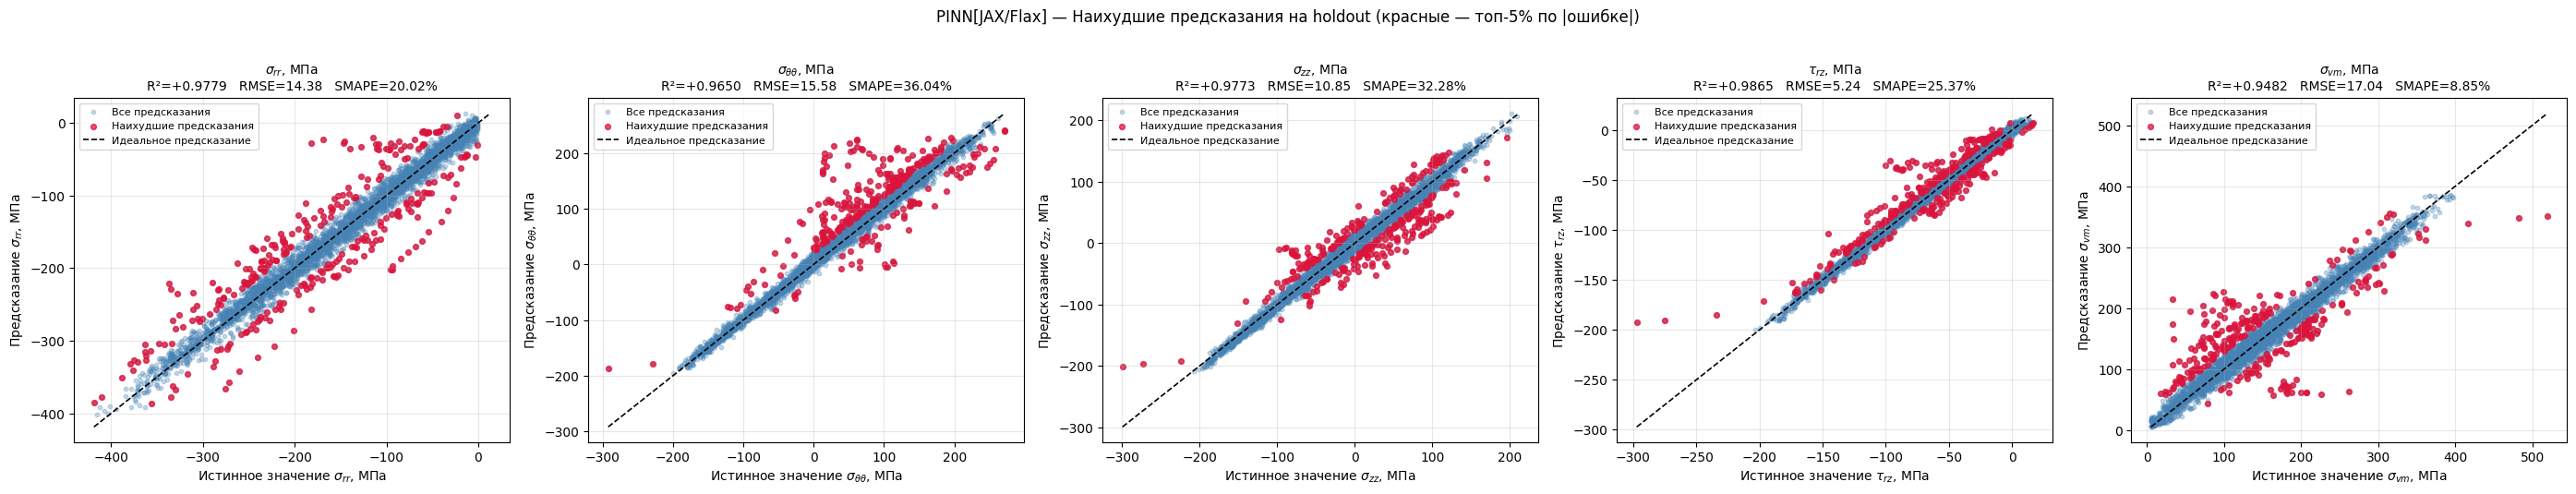


══════════════════════════════════════════════════════════════════════════
ПОКОМПОНЕНТНЫЕ ТАБЛИЦЫ НАИХУДШИХ ПРЕДСКАЗАНИЙ
══════════════════════════════════════════════════════════════════════════

── Топ-10 наихудших по $\sigma_{rr}$, МПа  (из 304 всего) ──
 set_id  r_idx     Q   k  alpha   mu   v       r  y_true  y_pred  abs_err  rel_err_%
    553      1  0.25   0      4  0.1  10 0.05263  -182.5  -27.38    155.1      84.99
    553      4  0.25   0      4  0.1  10  0.2105  -168.6   -22.2    146.4      86.83
    553      2  0.25   0      4  0.1  10  0.1053  -145.8  -25.11    120.7      82.78
    553      0  0.25   0      4  0.1  10       0  -146.4  -28.47    117.9      80.54
   2005      0   0.1   1     16  0.1   5       0    -337  -220.7    116.3      34.52
   1646      1 0.025 0.3     20 0.05 250 0.05263  -93.17  -201.5    108.4      116.3
   1646      0 0.025 0.3     20 0.05 250       0  -95.75  -202.2    106.5      111.2
   2005      1   0.1   1     16  0.1   5 0.05263    -335  -22

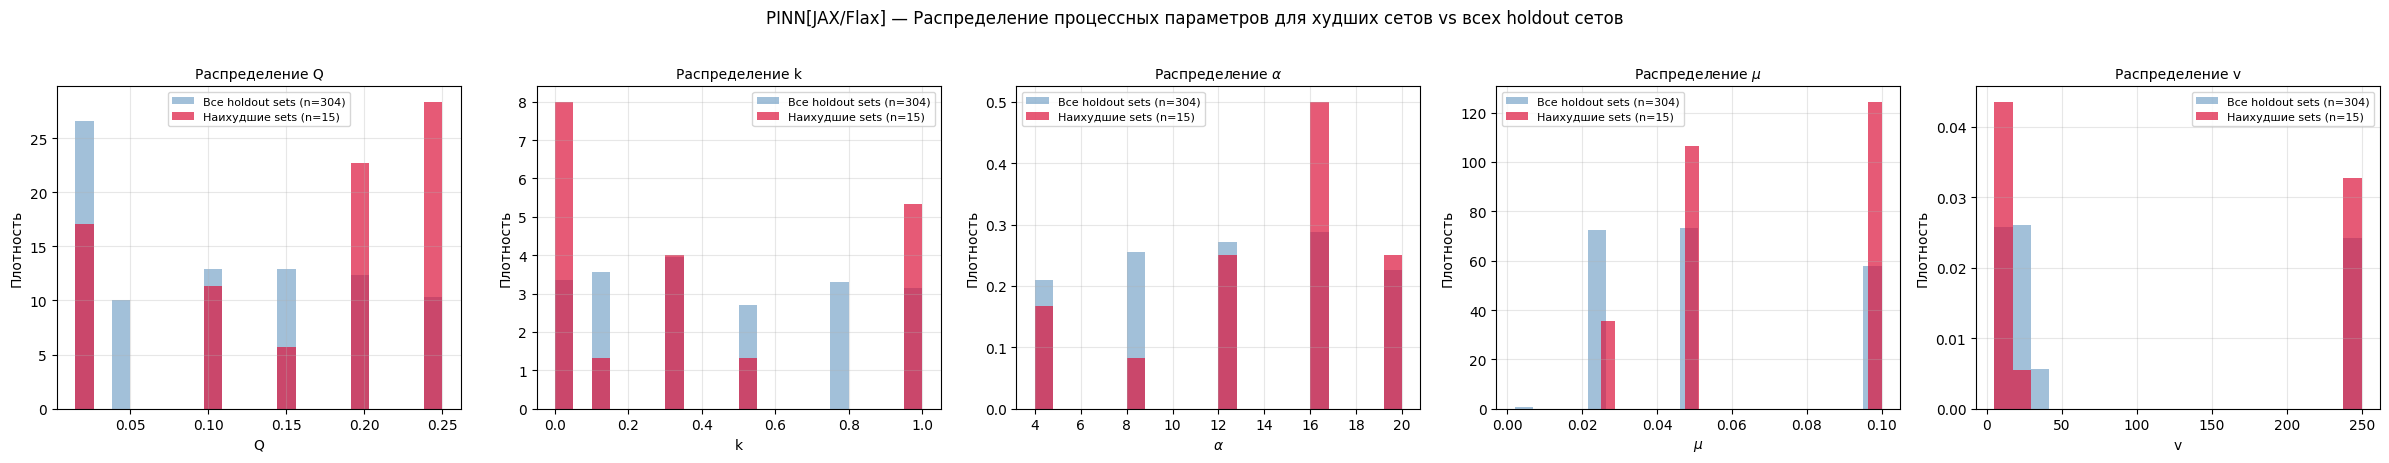

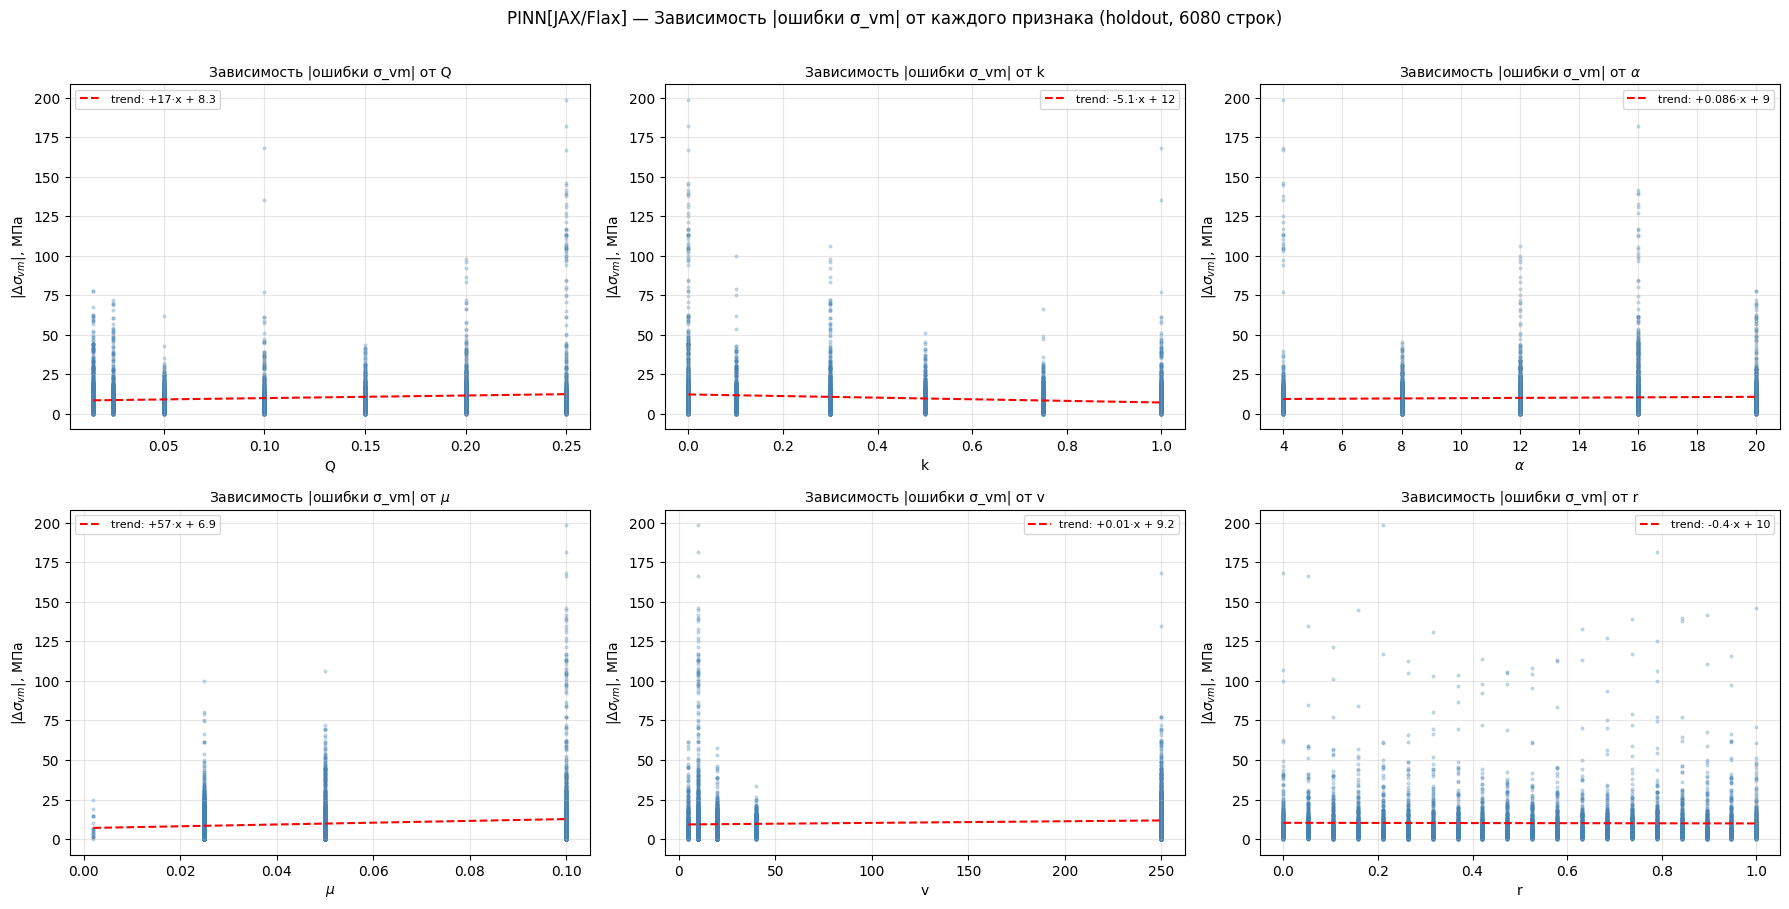


══════════════════════════════════════════════════════════════════════════
ОШИБКИ В ГРАНИЧНЫХ vs ВНУТРЕННИХ ТОЧКАХ ПРОЦЕССНОГО ПРОСТРАНСТВА
══════════════════════════════════════════════════════════════════════════
  граничные сеты :  304  (100.0% holdout), mean |err|_macro = 6.61 МПа
  внутренние сеты:    0  (0.0% holdout), mean |err|_macro = nan МПа

✓ Сохранено: worst_sets_pinn_jax.csv  (15 строк)
✓ Сохранено: all_holdout_sets_errors_pinn_jax.csv  (304 строк)

══════════════════════════════════════════════════════════════════════════
AUDIT ЗАВЕРШЁН. Файлы: worst_predictions_scatter_pinn_jax.png, worst_sets_param_histograms_pinn_jax.png, error_vs_features_pinn_jax.png, worst_sets_pinn_jax.csv, all_holdout_sets_errors_pinn_jax.csv
══════════════════════════════════════════════════════════════════════════


/tmp/ipykernel_2396/2110235531.py:285: RuntimeWarning: Mean of empty slice.
  f"mean |err|_macro = {inn_err.mean():.2f} МПа")
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import importlib
import pickle
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from sklearn.metrics import r2_score, mean_squared_error

import pinn_model_jax
importlib.reload(pinn_model_jax)
from pinn_model_jax import (
    build_stress_dataset,
    predict_with_pinn_jax,
    von_mises_stress,
    smape,
    OutputScaler,
    PINNNetwork,
    N_R,
    PLANE_ORDER,
    STRESS_COMPONENTS,
)

MODEL_TAG  = "PINN[JAX/Flax]"
MODEL_PATH = Path("./artifacts/pinn_model_jax.pkl")
WORST_FRAC = 0.05


print("═" * 74)
print(f"WORST-PREDICTIONS AUDIT  —  {MODEL_TAG}")
print("═" * 74)

with open(MODEL_PATH, "rb") as f:
    bundle = pickle.load(f)

devices = jax.devices()
gpu_devices = [d for d in devices if d.platform == "gpu"]
device_label = str(gpu_devices[0].device_kind) if gpu_devices else "cpu"

layer_sizes = tuple(bundle["layer_sizes"])
activation  = bundle["activation"]

params_jax = jax.tree_util.tree_map(jnp.asarray, bundle["flax_params_numpy"])
state = SimpleNamespace(params=params_jax)

net = PINNNetwork(layer_sizes=layer_sizes, activation=activation)

mean_X = jnp.asarray(bundle["mean_X"])
std_X  = jnp.asarray(bundle["std_X"])
scaler_y = OutputScaler()
scaler_y.mean_ = bundle["scaler_y_mean"]
scaler_y.std_  = bundle["scaler_y_std"]

hold_sets   = bundle["holdout_set_indices"]
plane_order = bundle["plane_order"]
already_removed = bundle.get("removed_set_indices", [])
assert plane_order == PLANE_ORDER, "PLANE_ORDER mismatch"

print(f"  device         : {device_label}")
print(f"  jax version    : {jax.__version__}")
print(f"  layer_sizes    : {list(layer_sizes)}")
print(f"  activation     : {activation}")
print(f"  framework      : {bundle.get('framework', 'jax_flax')}  "
      f"(version={bundle.get('version', '?')})")
print(f"  holdout sets   : {len(hold_sets)}  (sorted indices, seed={bundle['split_seed']})")
print(f"  holdout rows   : {len(hold_sets) * N_R}")
print(f"  removed earlier: {already_removed}")


X_pinn, y_pinn, r_grid, proc_all = build_stress_dataset(
    X_stress, y_stress, n_r=N_R, verbose=False,
)
hold_rows = np.concatenate([np.arange(s * N_R, (s + 1) * N_R) for s in hold_sets])
X_hold = X_pinn[hold_rows]
y_hold = y_pinn[hold_rows]

pred = predict_with_pinn_jax(state, net, X_hold, mean_X, std_X, scaler_y)
y_pred  = pred["sigma"]
vm_true = von_mises_stress(y_hold)
vm_pred = von_mises_stress(y_pred)

print(f"\n  X_hold         : {X_hold.shape}")
print(f"  y_hold         : {y_hold.shape}")
print(f"  y_pred         : {y_pred.shape}")


FEATURE_NAMES = ["Q", "k", r"$\alpha$", r"$\mu$", "v", "r"]
FEATURE_KEYS  = ["Q", "k", "alpha", "mu", "v", "r"]

set_id_per_row = np.repeat(hold_sets, N_R)
r_idx_per_row  = np.tile(np.arange(N_R), len(hold_sets))

abs_err    = np.abs(y_hold - y_pred)
abs_err_vm = np.abs(vm_true - vm_pred)
eps_rel    = 1.0
rel_err    = 100.0 * abs_err / np.maximum(np.abs(y_hold), eps_rel)

base_df = pd.DataFrame({
    "set_id": set_id_per_row,
    "r_idx":  r_idx_per_row,
    **{FEATURE_KEYS[i]: X_hold[:, i] for i in range(6)},
})


comp_titles = [
    r"$\sigma_{rr}$, МПа",
    r"$\sigma_{\theta\theta}$, МПа",
    r"$\sigma_{zz}$, МПа",
    r"$\tau_{rz}$, МПа",
    r"$\sigma_{vm}$, МПа",
]
comp_data = [
    (y_hold[:, 0], y_pred[:, 0], abs_err[:, 0]),
    (y_hold[:, 1], y_pred[:, 1], abs_err[:, 1]),
    (y_hold[:, 2], y_pred[:, 2], abs_err[:, 2]),
    (y_hold[:, 3], y_pred[:, 3], abs_err[:, 3]),
    (vm_true,      vm_pred,      abs_err_vm),
]

n_total = len(y_hold)
n_worst = max(int(n_total * WORST_FRAC), 10)
print(f"\n  WORST_FRAC      : {WORST_FRAC:.1%}")
print(f"  n_worst (per component): {n_worst} строк из {n_total}")

fig, axes = plt.subplots(1, 5, figsize=(28, 5.2))
worst_indices_per_comp = {}

for ax, title, (yt, yp, ae) in zip(axes, comp_titles, comp_data):
    wi = np.argsort(ae)[-n_worst:]
    worst_indices_per_comp[title] = wi
    ax.scatter(yt, yp, s=10, alpha=0.3, color="steelblue",
                label="Все предсказания")
    ax.scatter(yt[wi], yp[wi], s=18, alpha=0.75, color="crimson",
                label="Наихудшие предсказания")
    lo, hi = min(yt.min(), yp.min()), max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1.2, label="Идеальное предсказание")
    r2 = r2_score(yt, yp); rm = np.sqrt(mean_squared_error(yt, yp)); sm = smape(yt, yp)
    ax.set_xlabel(f"Истинное значение {title}")
    ax.set_ylabel(f"Предсказание {title}")
    ax.set_title(f"{title}\nR²={r2:+.4f}   RMSE={rm:.2f}   SMAPE={sm:.2f}%",
                 fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8, loc="best")

plt.suptitle(f"{MODEL_TAG} — Наихудшие предсказания на holdout "
             f"(красные — топ-{WORST_FRAC:.0%} по |ошибке|)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("worst_predictions_scatter_pinn_jax.png", dpi=300, bbox_inches="tight")
plt.show()


def make_worst_table(title, yt, yp, ae, n_show=10):
    wi = np.argsort(ae)[-n_worst:]
    df = base_df.iloc[wi].copy()
    df["y_true"]    = yt[wi]
    df["y_pred"]    = yp[wi]
    df["abs_err"]   = ae[wi]
    df["rel_err_%"] = 100.0 * ae[wi] / np.maximum(np.abs(yt[wi]), eps_rel)
    df = df.sort_values("abs_err", ascending=False).reset_index(drop=True)
    print(f"\n── Топ-{n_show} наихудших по {title}  (из {n_worst} всего) ──")
    with pd.option_context("display.max_columns", None, "display.width", 200,
                            "display.float_format", "{:,.4g}".format):
        print(df.head(n_show).to_string(index=False))
    return df

print("\n" + "═" * 74)
print("ПОКОМПОНЕНТНЫЕ ТАБЛИЦЫ НАИХУДШИХ ПРЕДСКАЗАНИЙ")
print("═" * 74)
worst_tables = {t: make_worst_table(t, yt, yp, ae, n_show=10)
                 for t, (yt, yp, ae) in zip(comp_titles, comp_data)}


print("\n" + "═" * 74)
print("PER-SET АГРЕГАЦИЯ — mean / max |err| по 20 r-точкам одного FEM-расчёта")
print("═" * 74)

ae_by_set      = abs_err.reshape(len(hold_sets), N_R, 4)
ae_by_set_mean = ae_by_set.mean(axis=1)
ae_by_set_max  = ae_by_set.max(axis=1)
ae_vm_by_set   = abs_err_vm.reshape(len(hold_sets), N_R)
ae_vm_set_mean = ae_vm_by_set.mean(axis=1)
ae_vm_set_max  = ae_vm_by_set.max(axis=1)

set_df = pd.DataFrame({"set_id": hold_sets})
for i, key in enumerate(FEATURE_KEYS[:5]):
    set_df[key] = proc_all[hold_sets, i]
for i, name in enumerate(STRESS_COMPONENTS):
    set_df[f"mean_err_{name}"] = ae_by_set_mean[:, i]
    set_df[f"max_err_{name}"]  = ae_by_set_max[:, i]
set_df["mean_err_vm"]    = ae_vm_set_mean
set_df["max_err_vm"]     = ae_vm_set_max
set_df["mean_err_macro"] = ae_by_set_mean.mean(axis=1)

n_worst_sets = max(int(len(hold_sets) * WORST_FRAC), 5)
worst_sets_df = set_df.nlargest(n_worst_sets, "mean_err_macro").reset_index(drop=True)
print(f"\nТоп-{n_worst_sets} наихудших СЕТОВ holdout (по mean_err_macro):")
with pd.option_context("display.max_columns", None, "display.width", 220,
                        "display.float_format", "{:,.4g}".format):
    cols_show = ["set_id", "Q", "k", "alpha", "mu", "v",
                  "mean_err_macro", "mean_err_vm", "max_err_vm"]
    print(worst_sets_df[cols_show].to_string(index=False))


fig, axes = plt.subplots(1, 5, figsize=(24, 4.5))
param_labels = ["Q", "k", r"$\alpha$", r"$\mu$", "v"]

for ax, key, label in zip(axes, FEATURE_KEYS[:5], param_labels):
    all_vals   = set_df[key].values
    worst_vals = worst_sets_df[key].values
    bins = 20
    ax.hist(all_vals, bins=bins, alpha=0.5, color="steelblue",
            label=f"Все holdout sets (n={len(all_vals)})", density=True)
    ax.hist(worst_vals, bins=bins, alpha=0.7, color="crimson",
            label=f"Наихудшие sets (n={len(worst_vals)})", density=True)
    ax.set_xlabel(label); ax.set_ylabel("Плотность")
    ax.set_title(f"Распределение {label}", fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle(f"{MODEL_TAG} — Распределение процессных параметров для худших сетов "
             f"vs всех holdout сетов",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("worst_sets_param_histograms_pinn_jax.png", dpi=300, bbox_inches="tight")
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

ae_macro = abs_err.mean(axis=1)
plot_df = base_df.copy()
plot_df["abs_err_macro"] = ae_macro
plot_df["abs_err_vm"]    = abs_err_vm

for ax, key, label in zip(axes[:6], FEATURE_KEYS, FEATURE_NAMES):
    ax.scatter(plot_df[key].values, plot_df["abs_err_vm"].values,
                s=4, alpha=0.25, color="steelblue")
    x = plot_df[key].values; y = plot_df["abs_err_vm"].values
    if x.std() > 1e-6:
        z = np.polyfit(x, y, 1)
        x_line = np.linspace(x.min(), x.max(), 50)
        ax.plot(x_line, np.poly1d(z)(x_line),
                "r--", lw=1.5, label=f"trend: {z[0]:+.2g}·x + {z[1]:.2g}")
    ax.set_xlabel(label); ax.set_ylabel(r"$|\Delta\sigma_{vm}|$, МПа")
    ax.set_title(f"Зависимость |ошибки σ_vm| от {label}", fontsize=10)
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle(f"{MODEL_TAG} — Зависимость |ошибки σ_vm| от каждого признака "
             f"(holdout, {n_total} строк)",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig("error_vs_features_pinn_jax.png", dpi=300, bbox_inches="tight")
plt.show()


print("\n" + "═" * 74)
print("ОШИБКИ В ГРАНИЧНЫХ vs ВНУТРЕННИХ ТОЧКАХ ПРОЦЕССНОГО ПРОСТРАНСТВА")
print("═" * 74)

def is_boundary_row(arr_col, thresh=0.10):
    lo, hi = arr_col.min(), arr_col.max()
    rng = hi - lo
    if rng < 1e-12:
        return np.zeros_like(arr_col, dtype=bool)
    return (arr_col <= lo + thresh * rng) | (arr_col >= hi - thresh * rng)

boundary_set_mask = np.zeros(len(hold_sets), dtype=bool)
for key in FEATURE_KEYS[:5]:
    boundary_set_mask |= is_boundary_row(set_df[key].values)

bnd_err = set_df.loc[boundary_set_mask,  "mean_err_macro"].values
inn_err = set_df.loc[~boundary_set_mask, "mean_err_macro"].values

print(f"  граничные сеты : {boundary_set_mask.sum():4d}  "
      f"({100*boundary_set_mask.sum()/len(hold_sets):.1f}% holdout), "
      f"mean |err|_macro = {bnd_err.mean():.2f} МПа")
print(f"  внутренние сеты: {(~boundary_set_mask).sum():4d}  "
      f"({100*(~boundary_set_mask).sum()/len(hold_sets):.1f}% holdout), "
      f"mean |err|_macro = {inn_err.mean():.2f} МПа")
if len(inn_err) > 0 and inn_err.mean() > 1e-12:
    ratio = bnd_err.mean() / inn_err.mean()
    print(f"  отношение      : {ratio:.2f}×  (граница / внутренние)")


out_csv_worst_sets = "worst_sets_pinn_jax.csv"
worst_sets_df.to_csv(out_csv_worst_sets, index=False, float_format="%.4g")
print(f"\n✓ Сохранено: {out_csv_worst_sets}  ({len(worst_sets_df)} строк)")

out_csv_all_sets = "all_holdout_sets_errors_pinn_jax.csv"
set_df.to_csv(out_csv_all_sets, index=False, float_format="%.4g")
print(f"✓ Сохранено: {out_csv_all_sets}  ({len(set_df)} строк)")

print("\n" + "═" * 74)
print(f"AUDIT ЗАВЕРШЁН. Файлы: worst_predictions_scatter_pinn_jax.png, "
      f"worst_sets_param_histograms_pinn_jax.png, "
      f"error_vs_features_pinn_jax.png, {out_csv_worst_sets}, {out_csv_all_sets}")
print("═" * 74)